In [244]:
print("hi")


hi


In [245]:
import sys
print(sys.executable)

c:\Program Files\Python314\python.exe


In [246]:
import sys
!{sys.executable} -m pip install pandas

'c:\Program' is not recognized as an internal or external command,
operable program or batch file.


In [247]:
import sys
!"{sys.executable}" -m pip install pandas

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [248]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [249]:
bureau=pd.read_csv('bureau_data.csv')
customers=pd.read_csv('customers.csv')
loans=pd.read_csv('loans.csv')

In [250]:
bureau.head()
bureau.shape

(50000, 8)

In [251]:
customers.head()
customers.shape

(50000, 12)

In [252]:
loans

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,L49996,C49996,Personal,Unsecured,610000,535000,10700.0,96300,428000,22,385199,178470,2024-07-22,2024-08-15,False
49996,L49997,C49997,Auto,Secured,4211000,3243000,64860.0,583740,2594400,15,1656484,1040735,2024-07-22,2024-07-29,False
49997,L49998,C49998,Home,Secured,4097000,3740000,74800.0,673200,2992000,37,912691,355461,2024-07-22,2024-07-25,False
49998,L49999,C49999,Home,Secured,1871000,1630000,32600.0,293400,1304000,37,300035,179453,2024-07-22,2024-07-29,False


In [253]:
df=customers.merge(bureau,how='inner',on='cust_id')

In [254]:
df=df.merge(loans,how='inner',on='cust_id')

In [255]:
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001,1,1,42,0,0,3,7,L00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001,3,1,96,12,60,5,4,L00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001,2,1,82,24,147,6,58,L00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001,3,0,115,15,87,5,26,L00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001,4,2,120,0,0,5,10,L00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  number_of_open_accounts      50000 non-null  int64  
 13  number_of_closed

In [257]:
df['default']=df['default'].astype('int')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  number_of_open_accounts      50000 non-null  int64  
 13  number_of_closed

In [258]:
x=df.drop(columns='default')
y=df['default']

In [259]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42,stratify=y)

In [260]:
x_train.shape

(37500, 32)

In [261]:
x_test.shape

(12500, 32)

In [262]:
y_train.shape

(37500,)

In [263]:
y_test.shape

(12500,)

In [264]:
x_train=pd.DataFrame(x_train)

In [265]:
y_train=pd.DataFrame(y_train)

In [266]:
df_train=pd.concat([x_train,y_train],axis='columns')


In [267]:
df_test=pd.concat([x_test,y_test],axis='columns')

In [268]:
df_test.shape

(12500, 33)

In [269]:
df_test

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
19205,C19206,36,M,Married,Self-Employed,3728000,3,Owned,24,Jaipur,Rajasthan,302001,2,1,42,0,0,5,98,L19206,Home,Secured,12767000,9890000,197800.0,1780200,7912000,46,1745379,806208,2021-06-24,2021-07-23,0
15514,C15515,43,F,Single,Self-Employed,2493000,0,Owned,23,Delhi,Delhi,110001,4,0,125,0,0,5,32,L15515,Education,Secured,4295000,3087000,61740.0,555660,2469600,18,1675530,1019647,2021-02-09,2021-02-18,0
30367,C30368,30,M,Married,Self-Employed,3114000,4,Owned,27,Delhi,Delhi,110001,3,0,76,0,0,6,82,L30368,Auto,Secured,4486000,3323000,66460.0,598140,2658400,35,1613282,1000932,2022-08-06,2022-08-21,0
35347,C35348,37,F,Single,Salaried,570000,2,Owned,5,Pune,Maharashtra,411001,4,2,125,3,21,7,48,L35348,Home,Secured,2038000,1559000,31180.0,280620,1247200,46,398614,167679,2023-02-03,2023-02-04,0
41814,C41815,48,F,Single,Salaried,662000,0,Mortgage,23,Chennai,Tamil Nadu,600001,3,1,131,14,89,8,97,L41815,Home,Secured,1880000,1351000,27020.0,243180,1080800,44,383925,262180,2023-09-27,2023-10-17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,C29298,27,M,Single,Self-Employed,185000,0,Owned,3,Jaipur,Rajasthan,302001,3,0,104,5,14,8,52,L29298,Auto,Secured,265000,253000,5060.0,45540,202400,29,96645,65285,2022-06-28,2022-06-30,0
20567,C20568,40,M,Single,Self-Employed,430000,0,Rented,19,Kolkata,West Bengal,700001,1,1,10,0,0,5,5,L20568,Home,Secured,1458000,1363000,27260.0,245340,1090400,35,273282,158171,2021-08-13,2021-08-23,0
681,C00682,28,M,Married,Self-Employed,11961000,5,Rented,15,Bangalore,Karnataka,560001,2,2,32,2,7,4,54,L00682,Personal,Unsecured,5000000,3660000,73200.0,658800,2928000,15,2635199,4652930,2019-08-18,2019-09-16,0
33682,C33683,31,M,Single,Salaried,3430000,1,Owned,29,Delhi,Delhi,110001,1,0,36,0,0,4,85,L33683,Home,Secured,13849000,12534000,250680.0,2256120,10027200,37,1907851,1029321,2022-12-05,2022-12-17,0


In [270]:
df_test

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
19205,C19206,36,M,Married,Self-Employed,3728000,3,Owned,24,Jaipur,Rajasthan,302001,2,1,42,0,0,5,98,L19206,Home,Secured,12767000,9890000,197800.0,1780200,7912000,46,1745379,806208,2021-06-24,2021-07-23,0
15514,C15515,43,F,Single,Self-Employed,2493000,0,Owned,23,Delhi,Delhi,110001,4,0,125,0,0,5,32,L15515,Education,Secured,4295000,3087000,61740.0,555660,2469600,18,1675530,1019647,2021-02-09,2021-02-18,0
30367,C30368,30,M,Married,Self-Employed,3114000,4,Owned,27,Delhi,Delhi,110001,3,0,76,0,0,6,82,L30368,Auto,Secured,4486000,3323000,66460.0,598140,2658400,35,1613282,1000932,2022-08-06,2022-08-21,0
35347,C35348,37,F,Single,Salaried,570000,2,Owned,5,Pune,Maharashtra,411001,4,2,125,3,21,7,48,L35348,Home,Secured,2038000,1559000,31180.0,280620,1247200,46,398614,167679,2023-02-03,2023-02-04,0
41814,C41815,48,F,Single,Salaried,662000,0,Mortgage,23,Chennai,Tamil Nadu,600001,3,1,131,14,89,8,97,L41815,Home,Secured,1880000,1351000,27020.0,243180,1080800,44,383925,262180,2023-09-27,2023-10-17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,C29298,27,M,Single,Self-Employed,185000,0,Owned,3,Jaipur,Rajasthan,302001,3,0,104,5,14,8,52,L29298,Auto,Secured,265000,253000,5060.0,45540,202400,29,96645,65285,2022-06-28,2022-06-30,0
20567,C20568,40,M,Single,Self-Employed,430000,0,Rented,19,Kolkata,West Bengal,700001,1,1,10,0,0,5,5,L20568,Home,Secured,1458000,1363000,27260.0,245340,1090400,35,273282,158171,2021-08-13,2021-08-23,0
681,C00682,28,M,Married,Self-Employed,11961000,5,Rented,15,Bangalore,Karnataka,560001,2,2,32,2,7,4,54,L00682,Personal,Unsecured,5000000,3660000,73200.0,658800,2928000,15,2635199,4652930,2019-08-18,2019-09-16,0
33682,C33683,31,M,Single,Salaried,3430000,1,Owned,29,Delhi,Delhi,110001,1,0,36,0,0,4,85,L33683,Home,Secured,13849000,12534000,250680.0,2256120,10027200,37,1907851,1029321,2022-12-05,2022-12-17,0


In [271]:
df_train

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,Telangana,500001,4,2,152,20,118,4,36,L12747,Home,Secured,33121000,23442000,468840.0,4219560,18753600,28,5000000,4820526,2020-10-31,2020-11-11,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,Maharashtra,400001,3,1,160,10,62,5,5,L32496,Education,Secured,1175000,1149000,22980.0,206820,919200,50,467229,216697,2022-10-22,2022-10-27,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,Tamil Nadu,600001,1,1,54,12,67,4,0,L43676,Home,Secured,11409000,11296000,225920.0,2033280,9036800,32,1656773,1383842,2023-12-04,2023-12-29,0
9040,C09041,42,M,Married,Salaried,1500000,2,Mortgage,30,Bangalore,Karnataka,560001,3,0,76,0,0,8,87,L09041,Education,Secured,2336000,1695000,33900.0,305100,1356000,40,1023442,626203,2020-06-18,2020-07-07,0
13077,C13078,58,M,Married,Self-Employed,1817000,4,Owned,29,Pune,Maharashtra,411001,1,2,60,0,0,1,71,L13078,Personal,Unsecured,1167000,905000,18100.0,162900,724000,15,651599,585099,2020-11-12,2020-12-07,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,C28516,70,M,Single,Self-Employed,2470000,0,Owned,20,Kolkata,West Bengal,700001,2,0,40,0,0,5,13,L28516,Personal,Unsecured,1562000,1420000,28400.0,255600,1136000,12,1022399,501594,2022-05-30,2022-06-09,0
5558,C05559,39,F,Single,Salaried,2472000,0,Rented,26,Kolkata,West Bengal,700001,1,0,52,14,72,4,44,L05559,Auto,Secured,3208000,2753000,55060.0,495540,2202400,32,1123466,587429,2020-02-12,2020-02-17,0
45236,C45237,39,M,Married,Self-Employed,1329000,4,Owned,10,Pune,Maharashtra,411001,4,2,130,11,44,6,97,L45237,Home,Secured,4804000,4479000,89580.0,806220,3583200,38,913243,517025,2024-01-30,2024-02-04,1
49228,C49229,33,M,Single,Salaried,1274000,2,Owned,26,Chennai,Tamil Nadu,600001,2,1,88,0,0,6,25,L49229,Education,Secured,2451000,1890000,37800.0,340200,1512000,37,635515,475147,2024-06-24,2024-07-21,0


In [272]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37500 entries, 12746 to 37784
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      37500 non-null  object 
 1   age                          37500 non-null  int64  
 2   gender                       37500 non-null  object 
 3   marital_status               37500 non-null  object 
 4   employment_status            37500 non-null  object 
 5   income                       37500 non-null  int64  
 6   number_of_dependants         37500 non-null  int64  
 7   residence_type               37453 non-null  object 
 8   years_at_current_address     37500 non-null  int64  
 9   city                         37500 non-null  object 
 10  state                        37500 non-null  object 
 11  zipcode                      37500 non-null  int64  
 12  number_of_open_accounts      37500 non-null  int64  
 13  number_of_closed_

In [273]:
df_train.isnull().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd                       0
enquiry_count                   0
credit_utilization_ratio        0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_a

In [274]:
df_test

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
19205,C19206,36,M,Married,Self-Employed,3728000,3,Owned,24,Jaipur,Rajasthan,302001,2,1,42,0,0,5,98,L19206,Home,Secured,12767000,9890000,197800.0,1780200,7912000,46,1745379,806208,2021-06-24,2021-07-23,0
15514,C15515,43,F,Single,Self-Employed,2493000,0,Owned,23,Delhi,Delhi,110001,4,0,125,0,0,5,32,L15515,Education,Secured,4295000,3087000,61740.0,555660,2469600,18,1675530,1019647,2021-02-09,2021-02-18,0
30367,C30368,30,M,Married,Self-Employed,3114000,4,Owned,27,Delhi,Delhi,110001,3,0,76,0,0,6,82,L30368,Auto,Secured,4486000,3323000,66460.0,598140,2658400,35,1613282,1000932,2022-08-06,2022-08-21,0
35347,C35348,37,F,Single,Salaried,570000,2,Owned,5,Pune,Maharashtra,411001,4,2,125,3,21,7,48,L35348,Home,Secured,2038000,1559000,31180.0,280620,1247200,46,398614,167679,2023-02-03,2023-02-04,0
41814,C41815,48,F,Single,Salaried,662000,0,Mortgage,23,Chennai,Tamil Nadu,600001,3,1,131,14,89,8,97,L41815,Home,Secured,1880000,1351000,27020.0,243180,1080800,44,383925,262180,2023-09-27,2023-10-17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,C29298,27,M,Single,Self-Employed,185000,0,Owned,3,Jaipur,Rajasthan,302001,3,0,104,5,14,8,52,L29298,Auto,Secured,265000,253000,5060.0,45540,202400,29,96645,65285,2022-06-28,2022-06-30,0
20567,C20568,40,M,Single,Self-Employed,430000,0,Rented,19,Kolkata,West Bengal,700001,1,1,10,0,0,5,5,L20568,Home,Secured,1458000,1363000,27260.0,245340,1090400,35,273282,158171,2021-08-13,2021-08-23,0
681,C00682,28,M,Married,Self-Employed,11961000,5,Rented,15,Bangalore,Karnataka,560001,2,2,32,2,7,4,54,L00682,Personal,Unsecured,5000000,3660000,73200.0,658800,2928000,15,2635199,4652930,2019-08-18,2019-09-16,0
33682,C33683,31,M,Single,Salaried,3430000,1,Owned,29,Delhi,Delhi,110001,1,0,36,0,0,4,85,L33683,Home,Secured,13849000,12534000,250680.0,2256120,10027200,37,1907851,1029321,2022-12-05,2022-12-17,0


In [275]:
df_train.duplicated().sum()
df_test.duplicated().sum()

np.int64(0)

In [276]:
df_train.isna().sum()


cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd                       0
enquiry_count                   0
credit_utilization_ratio        0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_a

In [277]:
df_test.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 15
years_at_current_address        0
city                            0
state                           0
zipcode                         0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd                       0
enquiry_count                   0
credit_utilization_ratio        0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_a

In [278]:
df_train['residence_type'].unique()
df_test['residence_type'].unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [279]:
df_train['residence_type'].mode()[0]

'Owned'

In [280]:
df_train['residence_type']=df_train['residence_type'].fillna(df_train['residence_type'].mode()[0])


In [281]:
df_test['residence_type']=df_test['residence_type'].fillna(df_test['residence_type'].mode()[0])

In [282]:
df_test.shape

(12500, 33)

In [283]:
df_train.isnull().sum()


cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

In [284]:
df_test.isnull().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_count                  0
credit_utilization_ratio       0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_

In [285]:
df_test.shape

(12500, 33)

In [286]:
nums_cols=df_train.select_dtypes(include='number')
cat_cols=df_train.select_dtypes(include=['object'])

In [287]:
cat_cols

,cust_id,gender,marital_status,employment_status,residence_type,city,state,loan_id,loan_purpose,loan_type,disbursal_date,installment_start_dt
12746,C12747,M,Married,Self-Employed,Owned,Hyderabad,Telangana,L12747,Home,Secured,2020-10-31,2020-11-11
32495,C32496,F,Single,Salaried,Owned,Mumbai,Maharashtra,L32496,Education,Secured,2022-10-22,2022-10-27
43675,C43676,M,Single,Salaried,Mortgage,Chennai,Tamil Nadu,L43676,Home,Secured,2023-12-04,2023-12-29
9040,C09041,M,Married,Salaried,Mortgage,Bangalore,Karnataka,L09041,Education,Secured,2020-06-18,2020-07-07
13077,C13078,M,Married,Self-Employed,Owned,Pune,Maharashtra,L13078,Personal,Unsecured,2020-11-12,2020-12-07
...,...,...,...,...,...,...,...,...,...,...,...,...
28515,C28516,M,Single,Self-Employed,Owned,Kolkata,West Bengal,L28516,Personal,Unsecured,2022-05-30,2022-06-09
5558,C05559,F,Single,Salaried,Rented,Kolkata,West Bengal,L05559,Auto,Secured,2020-02-12,2020-02-17
45236,C45237,M,Married,Self-Employed,Owned,Pune,Maharashtra,L45237,Home,Secured,2024-01-30,2024-02-04
49228,C49229,M,Single,Salaried,Owned,Chennai,Tamil Nadu,L49229,Education,Secured,2024-06-24,2024-07-21


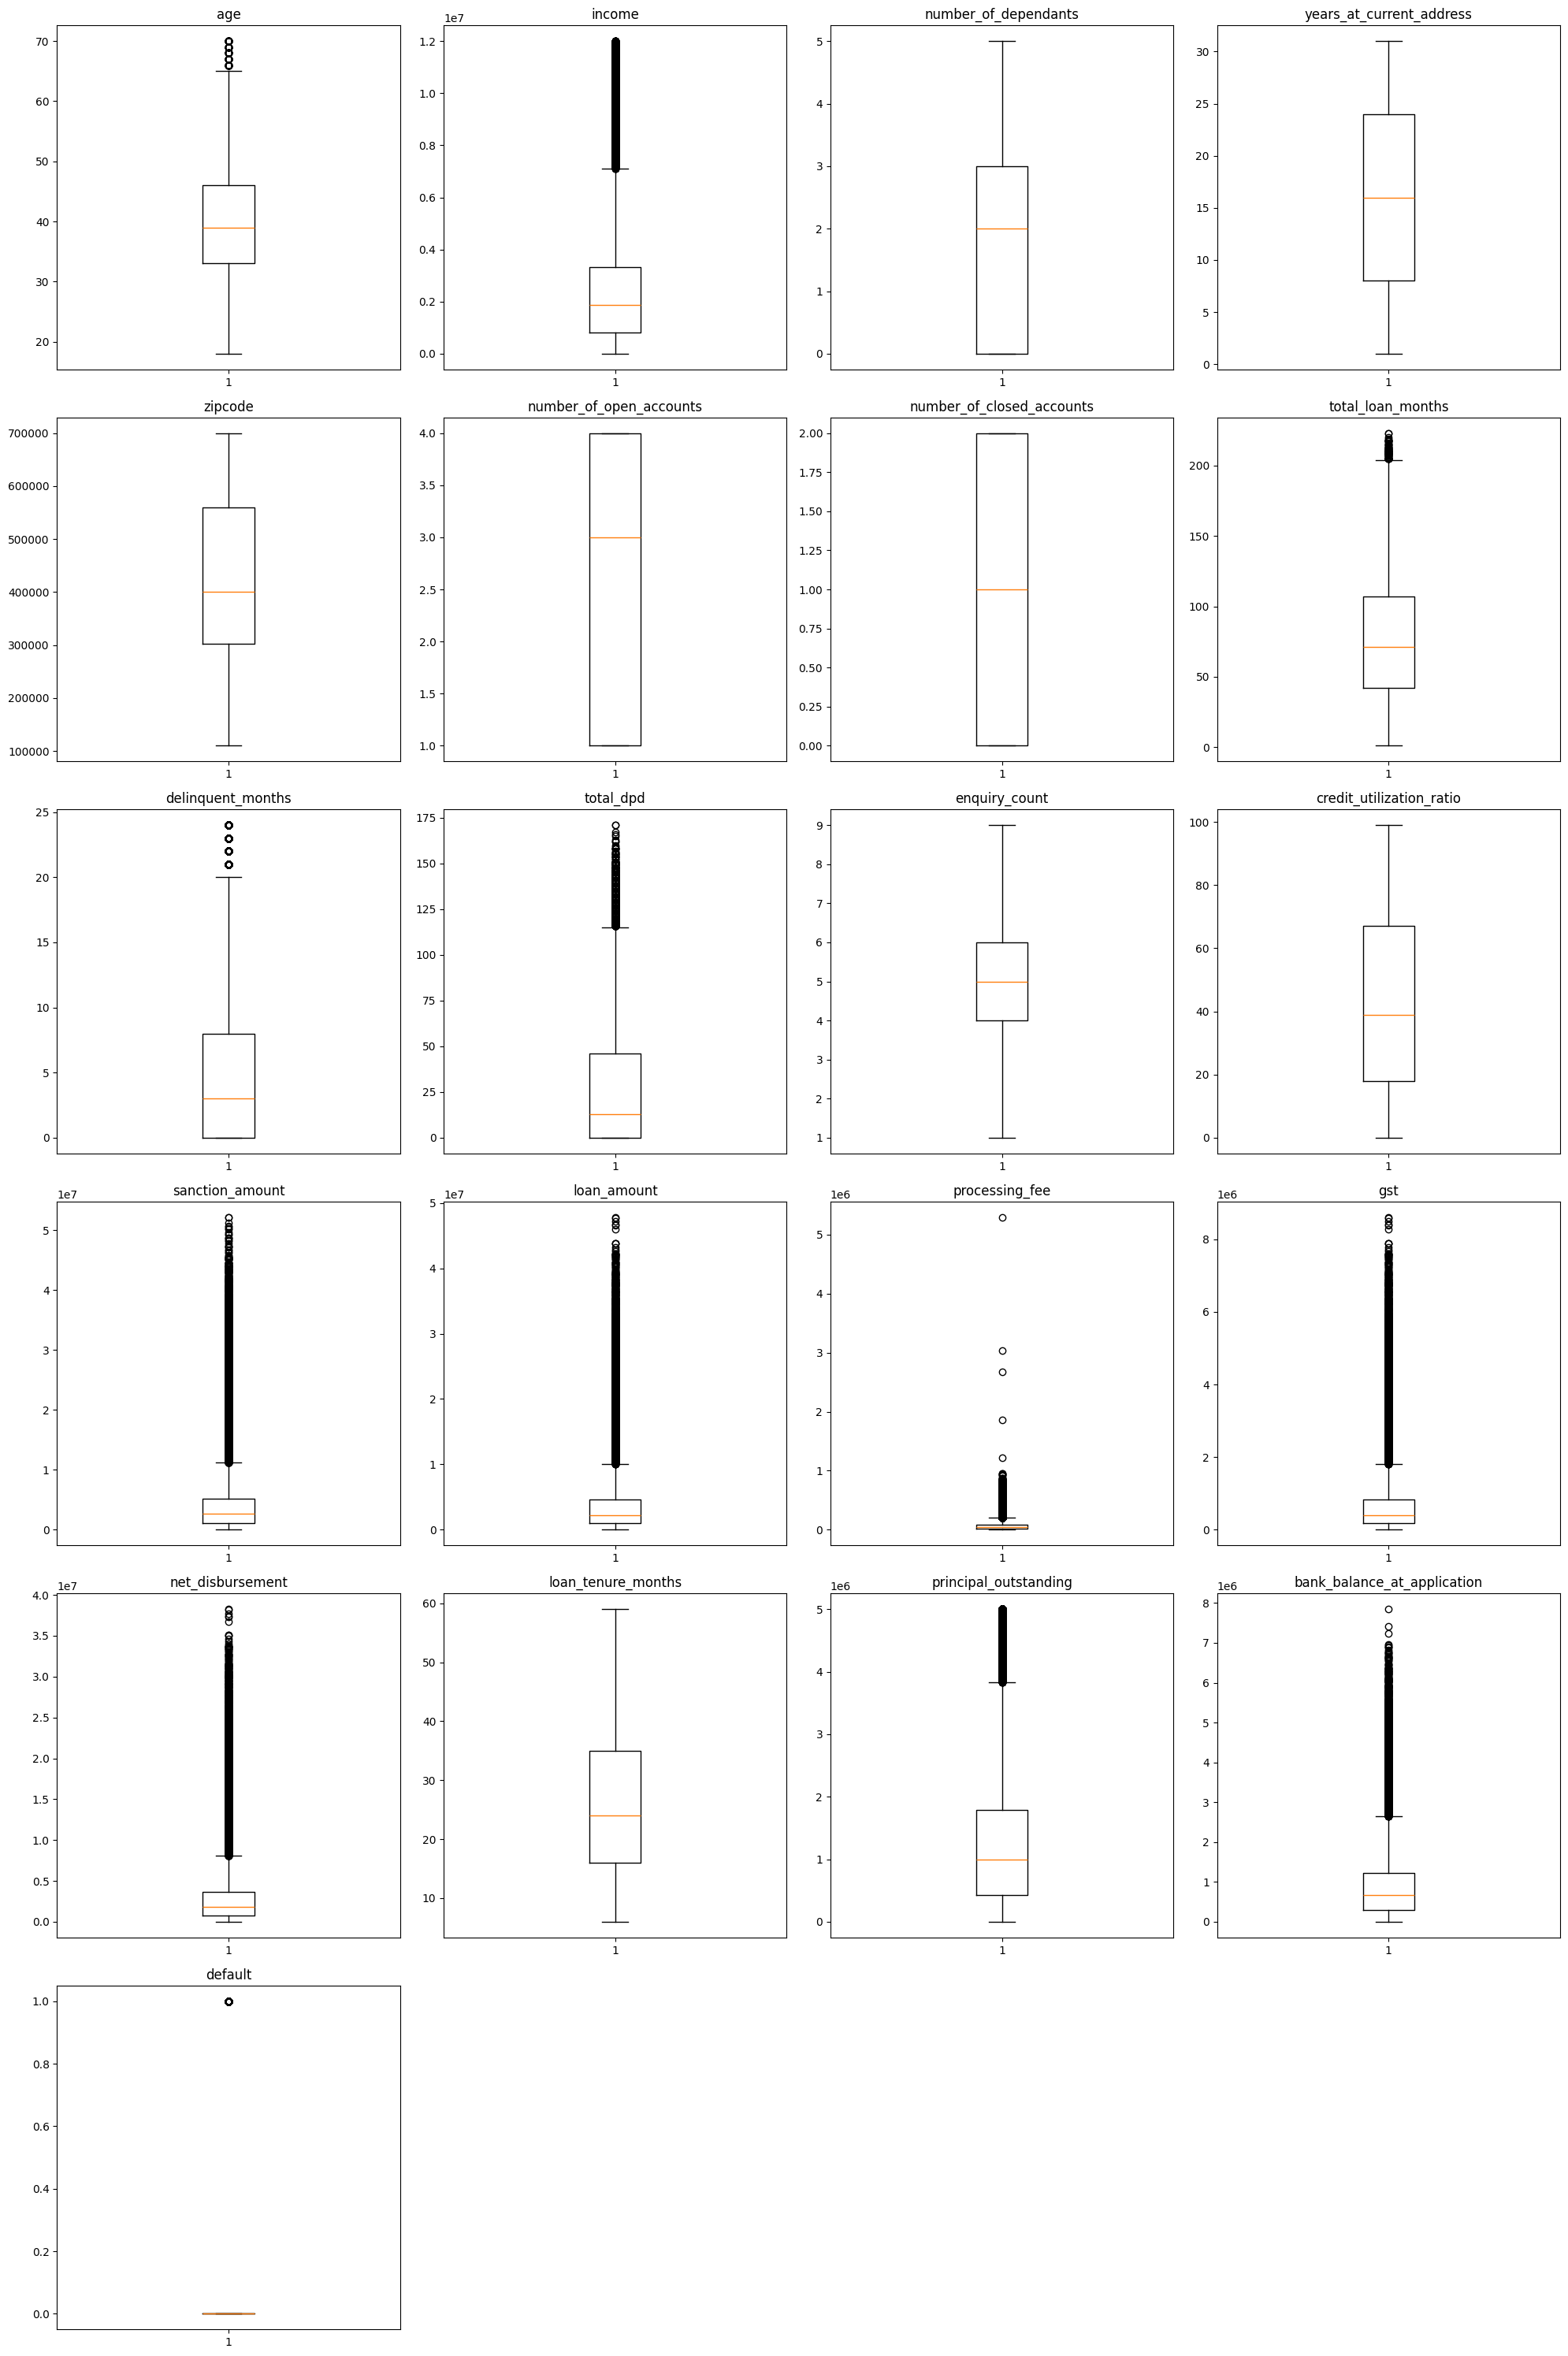

In [288]:
import matplotlib.pyplot as plt
import math

# Select numerical columns
num_cols = df_train.select_dtypes(include='number')

# Number of columns
n_cols = len(num_cols.columns)

# Set 4 plots per row
cols_per_row = 4
rows = math.ceil(n_cols / cols_per_row)

# Create figure
plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(num_cols.columns):
    plt.subplot(rows, cols_per_row, i + 1)
    plt.boxplot(num_cols[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

In [289]:
df_train[df_train['processing_fee']>df_train['loan_amount']]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
23981,C23982,33,F,Single,Self-Employed,1790000,0,Rented,7,Kolkata,West Bengal,700001,4,2,154,9,31,6,26,L23982,Auto,Secured,2649000,2234000,2.669791e+06,402120,1787200,32,920114,511339,2021-12-15,2022-01-14,0
28174,C28175,36,F,Single,Self-Employed,1123000,1,Rented,31,Hyderabad,Telangana,500001,3,0,111,8,41,3,62,L28175,Personal,Unsecured,1025000,966000,1.214493e+06,173880,772800,18,695519,390870,2022-05-18,2022-06-05,0
47089,C47090,37,M,Married,Self-Employed,1892000,2,Rented,13,Jaipur,Rajasthan,302001,3,0,112,5,33,3,32,L47090,Personal,Unsecured,1815000,1738000,1.858965e+06,312840,1390400,18,1032442,626462,2024-04-07,2024-04-15,0
29305,C29306,52,M,Married,Self-Employed,3839000,2,Owned,11,Delhi,Delhi,110001,2,2,42,11,65,3,2,L29306,Personal,Unsecured,2872000,2616000,3.036378e+06,470880,2092800,21,1883519,999324,2022-06-28,2022-07-21,0
9898,C09899,56,M,Married,Self-Employed,8948000,5,Owned,16,Ahmedabad,Gujarat,380001,2,1,51,1,5,3,92,L09899,Personal,Unsecured,5000000,3626000,5.293544e+06,652680,2900800,6,2610719,2849384,2020-07-19,2020-08-11,0


In [290]:
df_train=df_train[(df_train['processing_fee']/df_train['loan_amount'])<0.03]

In [291]:
df_train.shape

(37488, 33)

In [292]:
df_test=df_test[(df_test['processing_fee']/df_test['loan_amount'])<0.03]

In [293]:
df_test.shape

(12497, 33)

In [294]:
pd.set_option('display.max_columns',None)

In [295]:
for i in cat_cols: 
    print(i,df_train[i].unique())

cust_id ['C12747' 'C32496' 'C43676' ... 'C45237' 'C49229' 'C37785']
gender ['M' 'F']
marital_status ['Married' 'Single']
employment_status ['Self-Employed' 'Salaried']
residence_type ['Owned' 'Mortgage' 'Rented']
city ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
loan_id ['L12747' 'L32496' 'L43676' ... 'L45237' 'L49229' 'L37785']
loan_purpose ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type ['Secured' 'Unsecured']
disbursal_date ['2020-10-31' '2022-10-22' '2023-12-04' ... '2022-02-07' '2019-10-30'
 '2022-10-04']
installment_start_dt ['2020-11-11' '2022-10-27' '2023-12-29' ... '2024-08-19' '2019-07-28'
 '2019-07-25']


In [296]:
df_train[df_train['loan_purpose']=='Personaal']
df_test[df_test['loan_purpose']=='Personaal']

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
8871,C08872,40,F,Single,Self-Employed,917000,0,Mortgage,15,Pune,Maharashtra,411001,2,1,72,8,50,2,78,L08872,Personaal,Unsecured,817000,738000,14760.0,132840,590400,20,467413,316819,2020-06-12,2020-07-03,0
1224,C01225,38,F,Married,Self-Employed,7923000,3,Rented,11,Delhi,Delhi,110001,2,0,79,8,55,5,64,L01225,Personaal,Unsecured,5000000,4584000,91680.0,825120,3667200,20,3300479,3053853,2019-09-07,2019-09-25,0
16431,C16432,54,M,Married,Self-Employed,6929000,4,Owned,27,Pune,Maharashtra,411001,4,0,117,6,27,5,30,L16432,Personaal,Unsecured,5000000,4854000,97080.0,873720,3883200,21,3494879,2200217,2021-03-15,2021-03-16,0
36556,C36557,41,F,Single,Self-Employed,291000,0,Mortgage,2,Chennai,Tamil Nadu,600001,1,1,35,0,0,4,70,L36557,Personaal,Unsecured,233000,206000,4120.0,37080,164800,22,139575,109923,2023-03-19,2023-04-03,0


In [297]:
df_train['loan_purpose']=df_train['loan_purpose'].replace('Personaal','Personal',inplace=True)
df_test['loan_purpose']=df_test['loan_purpose'].replace('Personaal','Personal',inplace=True)

C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\1456225256.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['loan_purpose']=df_train['loan_purpose'].replace('Personaal','Personal',inplace=True)
C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\1456225256.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['loan_purpose']=df_train['loan_purpose'].replace('Personaal','Personal',inplace=True)
C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\1456225256.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

In [298]:
df_train['loan_purpose'].unique()

array([None], dtype=object)

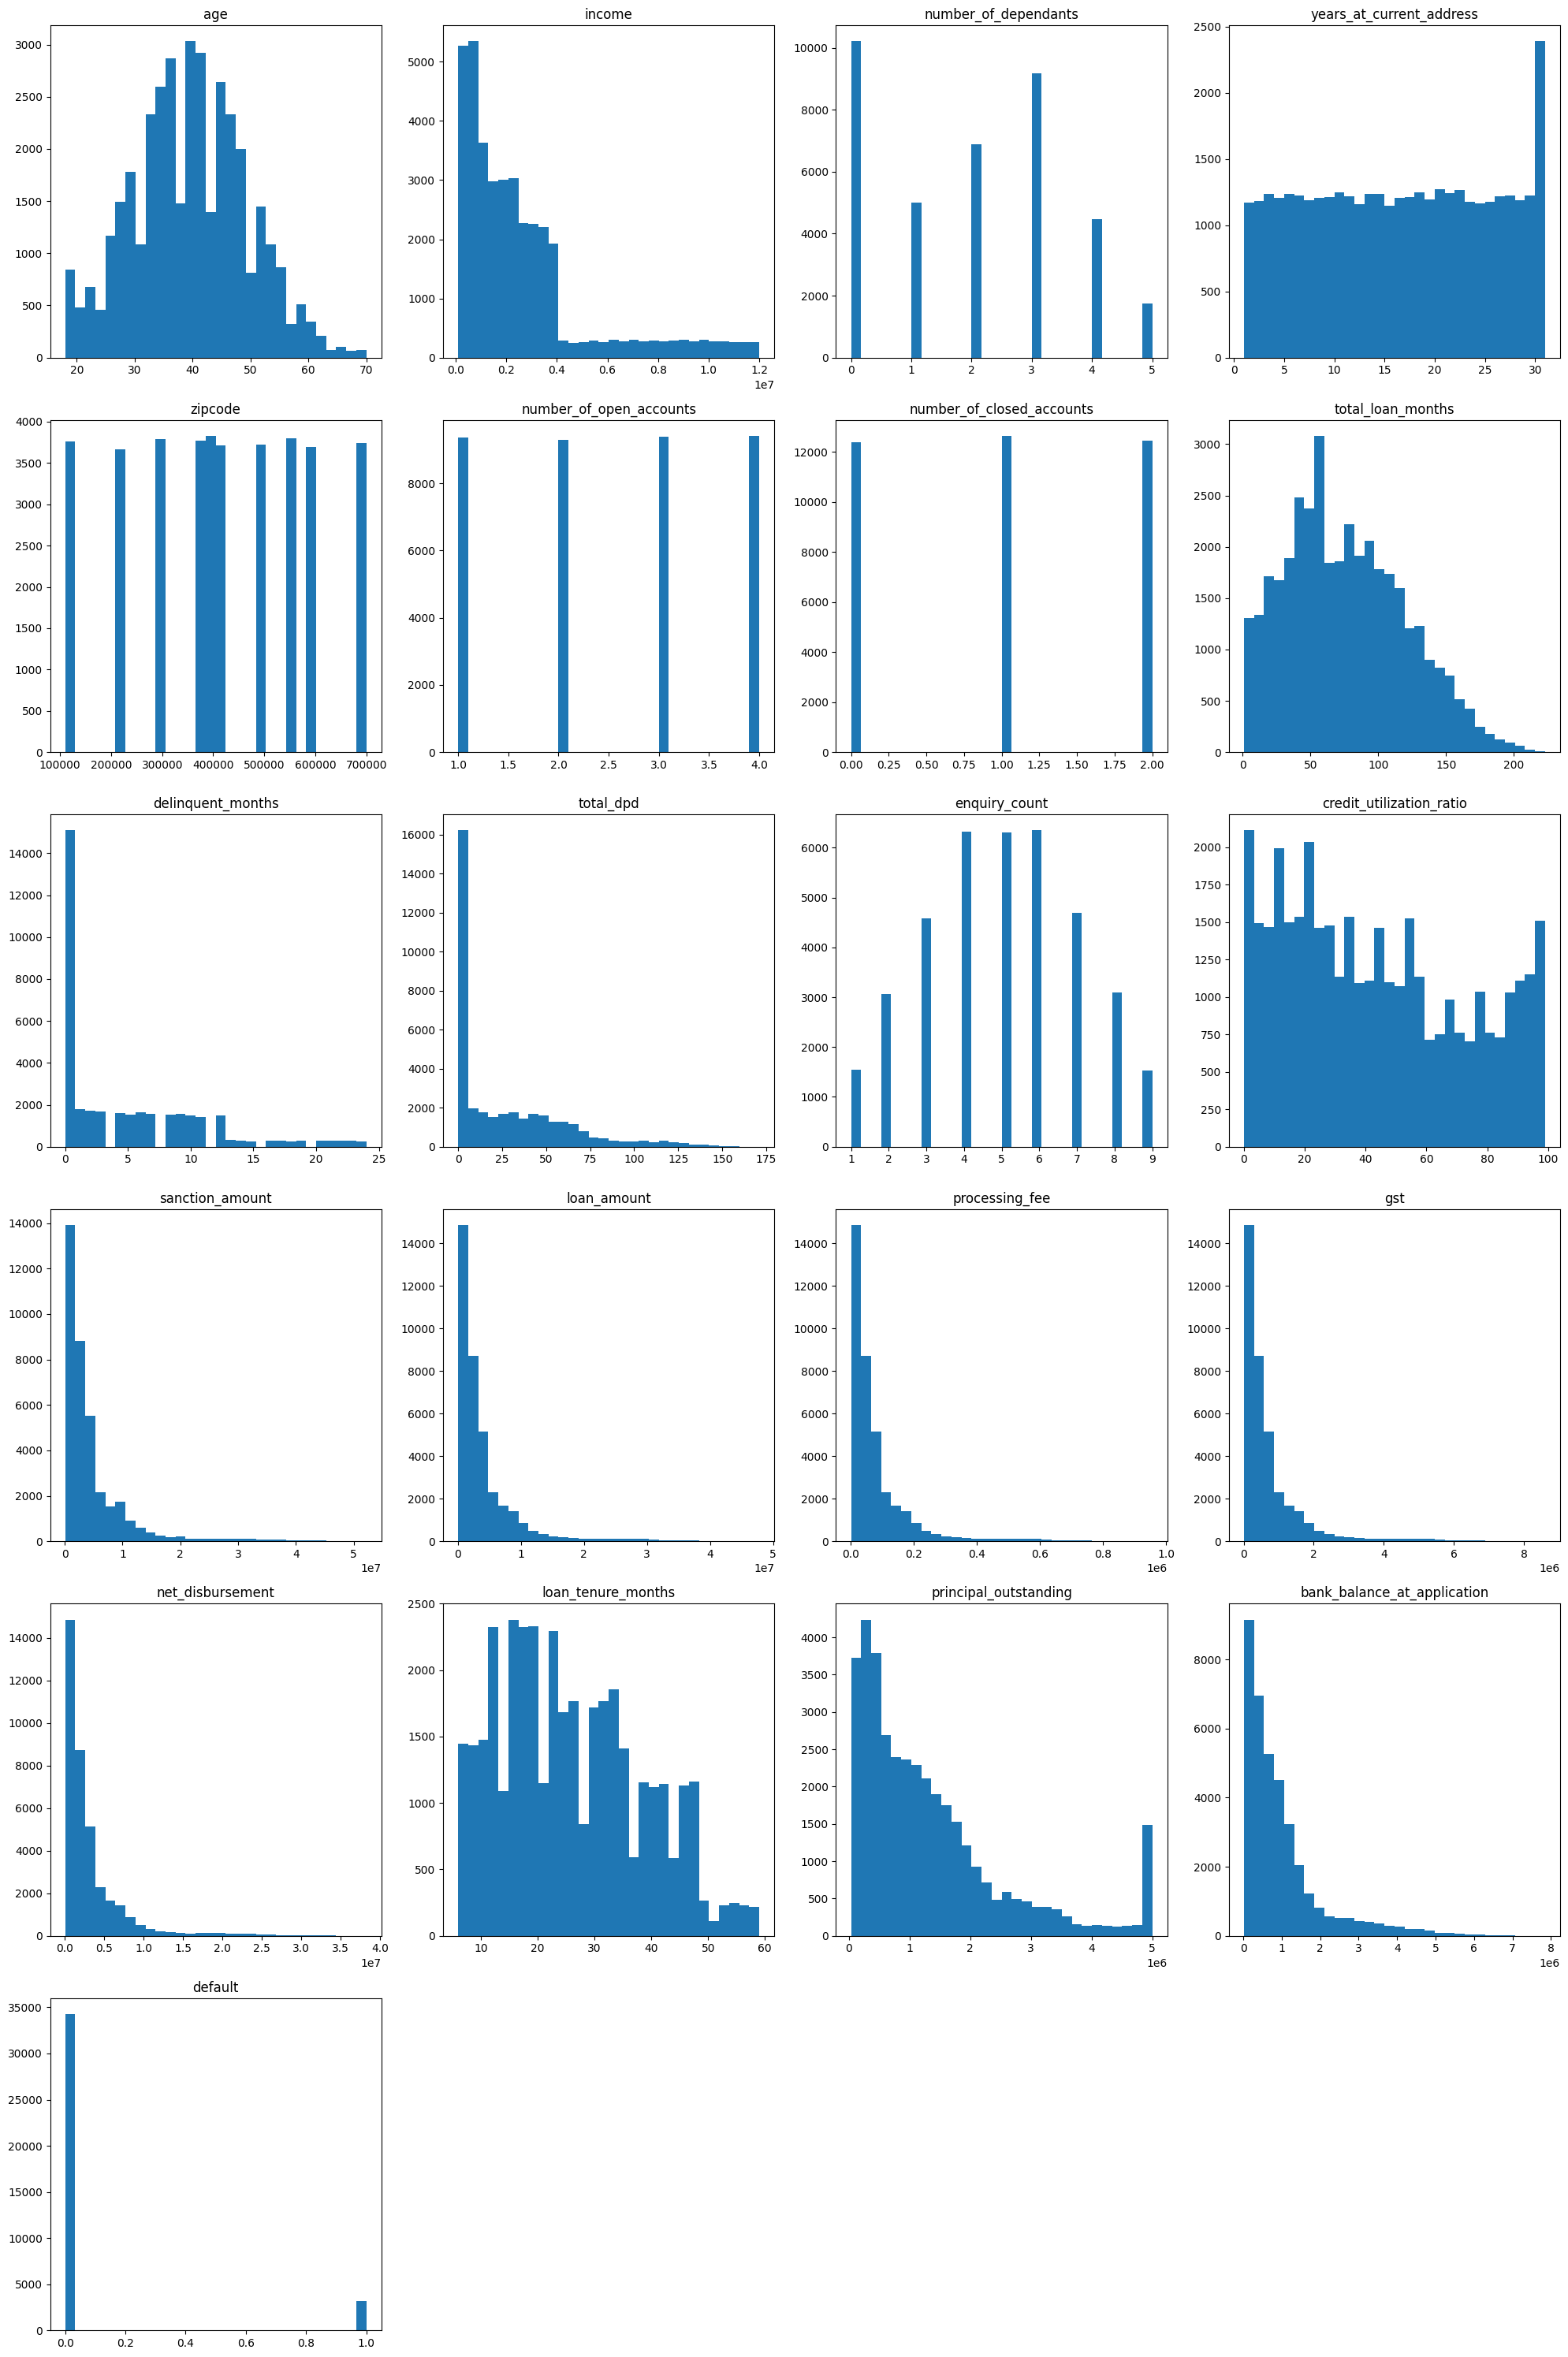

In [299]:
import matplotlib.pyplot as plt
import math

# Select numerical columns
num_cols = df_train.select_dtypes(include='number')

# Count columns
n_cols = len(num_cols.columns)

# 4 plots per row
cols_per_row = 4
rows = math.ceil(n_cols / cols_per_row)

# Create figure
plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(num_cols.columns):
    plt.subplot(rows, cols_per_row, i + 1)
    plt.hist(num_cols[col].dropna(), bins=30)
    plt.title(col)
    
plt.tight_layout()
plt.show()

In [300]:
num_cols

,age,income,number_of_dependants,years_at_current_address,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,default
12746,59,11327000,3,30,500001,4,2,152,20,118,4,36,33121000,23442000,468840.0,4219560,18753600,28,5000000,4820526,0
32495,44,715000,0,27,400001,3,1,160,10,62,5,5,1175000,1149000,22980.0,206820,919200,50,467229,216697,0
43675,38,3195000,0,26,600001,1,1,54,12,67,4,0,11409000,11296000,225920.0,2033280,9036800,32,1656773,1383842,0
9040,42,1500000,2,30,560001,3,0,76,0,0,8,87,2336000,1695000,33900.0,305100,1356000,40,1023442,626203,0
13077,58,1817000,4,29,411001,1,2,60,0,0,1,71,1167000,905000,18100.0,162900,724000,15,651599,585099,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,70,2470000,0,20,700001,2,0,40,0,0,5,13,1562000,1420000,28400.0,255600,1136000,12,1022399,501594,0
5558,39,2472000,0,26,700001,1,0,52,14,72,4,44,3208000,2753000,55060.0,495540,2202400,32,1123466,587429,0
45236,39,1329000,4,10,411001,4,2,130,11,44,6,97,4804000,4479000,89580.0,806220,3583200,38,913243,517025,1
49228,33,1274000,2,26,600001,2,1,88,0,0,6,25,2451000,1890000,37800.0,340200,1512000,37,635515,475147,0


**Exploratory Data Analysis**

<Axes: xlabel='age', ylabel='Density'>

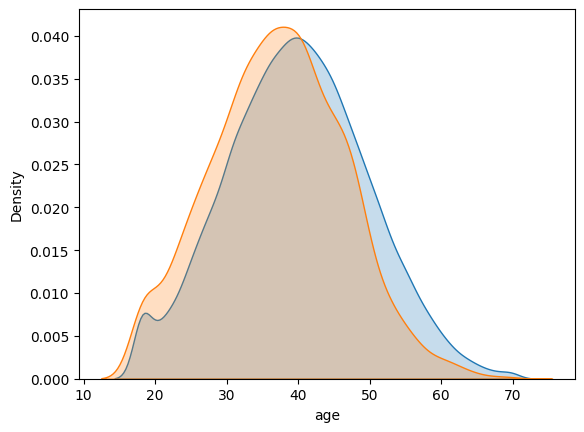

In [301]:
sns.kdeplot(df_train[df_train.default == 0]['age'], fill=True, label="default-0")
sns.kdeplot(df_train[df_train.default == 1]['age'], fill=True, label="default-1")

Insights
1. Orange graph is little bit shifted to left of blue graph which indicate people with young age are more likely to default

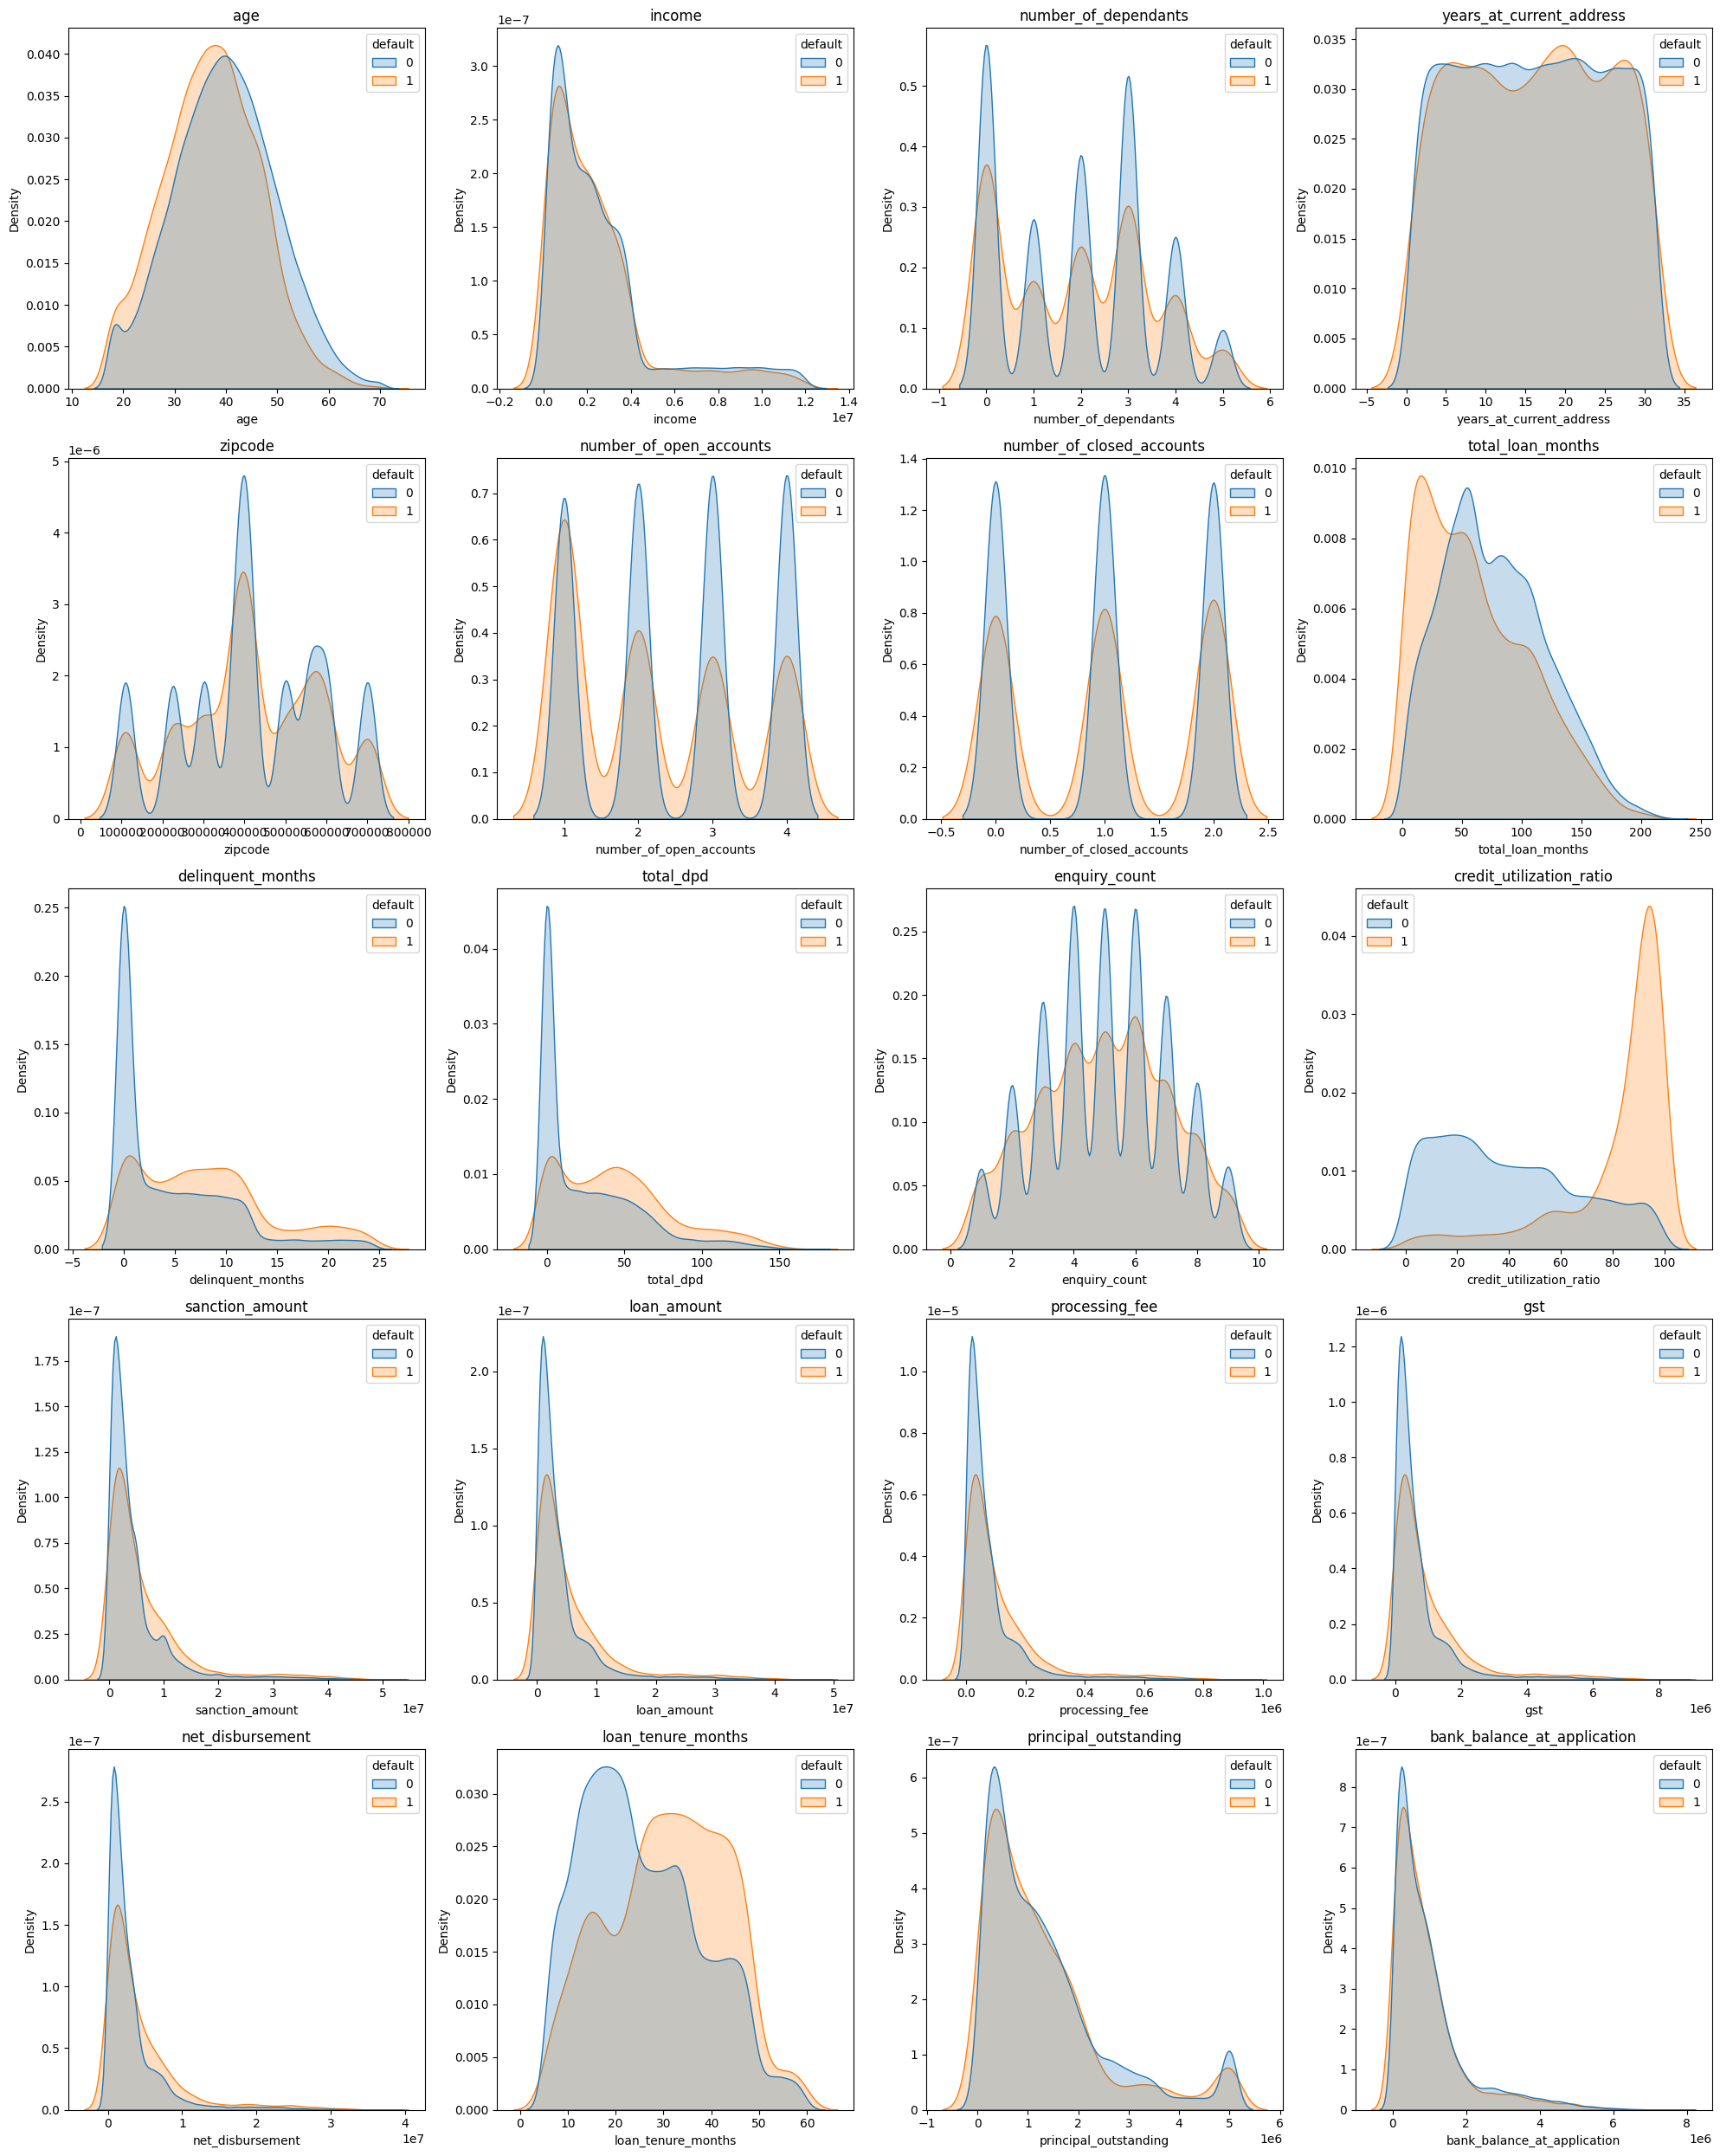

In [302]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select numerical columns
num_cols = df_train.select_dtypes(include='number').columns

# Remove target column if it's numeric
num_cols = [col for col in num_cols if col != 'default']

# Layout settings
cols_per_row = 4
rows = math.ceil(len(num_cols) / cols_per_row)

plt.figure(figsize=(20, 5 * rows))

for i, col in enumerate(num_cols):
    plt.subplot(rows, cols_per_row, i + 1)
    
    sns.kdeplot(
        data=df_train,
        x=col,
        hue='default',
        fill=True,
        common_norm=False
    )
    
    plt.title(col)

plt.tight_layout()
plt.show()

**Feature Engineering**

In [303]:
df_test

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
19205,C19206,36,M,Married,Self-Employed,3728000,3,Owned,24,Jaipur,Rajasthan,302001,2,1,42,0,0,5,98,L19206,None,Secured,12767000,9890000,197800.0,1780200,7912000,46,1745379,806208,2021-06-24,2021-07-23,0
15514,C15515,43,F,Single,Self-Employed,2493000,0,Owned,23,Delhi,Delhi,110001,4,0,125,0,0,5,32,L15515,None,Secured,4295000,3087000,61740.0,555660,2469600,18,1675530,1019647,2021-02-09,2021-02-18,0
30367,C30368,30,M,Married,Self-Employed,3114000,4,Owned,27,Delhi,Delhi,110001,3,0,76,0,0,6,82,L30368,None,Secured,4486000,3323000,66460.0,598140,2658400,35,1613282,1000932,2022-08-06,2022-08-21,0
35347,C35348,37,F,Single,Salaried,570000,2,Owned,5,Pune,Maharashtra,411001,4,2,125,3,21,7,48,L35348,None,Secured,2038000,1559000,31180.0,280620,1247200,46,398614,167679,2023-02-03,2023-02-04,0
41814,C41815,48,F,Single,Salaried,662000,0,Mortgage,23,Chennai,Tamil Nadu,600001,3,1,131,14,89,8,97,L41815,None,Secured,1880000,1351000,27020.0,243180,1080800,44,383925,262180,2023-09-27,2023-10-17,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,C29298,27,M,Single,Self-Employed,185000,0,Owned,3,Jaipur,Rajasthan,302001,3,0,104,5,14,8,52,L29298,None,Secured,265000,253000,5060.0,45540,202400,29,96645,65285,2022-06-28,2022-06-30,0
20567,C20568,40,M,Single,Self-Employed,430000,0,Rented,19,Kolkata,West Bengal,700001,1,1,10,0,0,5,5,L20568,None,Secured,1458000,1363000,27260.0,245340,1090400,35,273282,158171,2021-08-13,2021-08-23,0
681,C00682,28,M,Married,Self-Employed,11961000,5,Rented,15,Bangalore,Karnataka,560001,2,2,32,2,7,4,54,L00682,None,Unsecured,5000000,3660000,73200.0,658800,2928000,15,2635199,4652930,2019-08-18,2019-09-16,0
33682,C33683,31,M,Single,Salaried,3430000,1,Owned,29,Delhi,Delhi,110001,1,0,36,0,0,4,85,L33683,None,Secured,13849000,12534000,250680.0,2256120,10027200,37,1907851,1029321,2022-12-05,2022-12-17,0


In [304]:
df_train['Loan_to_Income']=df_train['loan_amount']/df_train['income']
df_test['Loan_to_Income']=df_test['loan_amount']/df_test['income']


C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\1264288148.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['Loan_to_Income']=df_train['loan_amount']/df_train['income']
C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\1264288148.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['Loan_to_Income']=df_test['loan_amount']/df_test['income']


In [305]:
df_train['Loan_to_Income'].describe()


count    37488.000000
mean         1.556697
std          0.973673
min          0.298028
25%          0.768518
50%          1.159751
75%          2.461120
max          4.565217
Name: Loan_to_Income, dtype: float64

In [306]:
df_test['Loan_to_Income'].describe()

count    12497.000000
mean         1.551275
std          0.965784
min          0.296170
25%          0.775100
50%          1.161664
75%          2.432384
max          4.591270
Name: Loan_to_Income, dtype: float64

<Axes: xlabel='Loan_to_Income', ylabel='Density'>

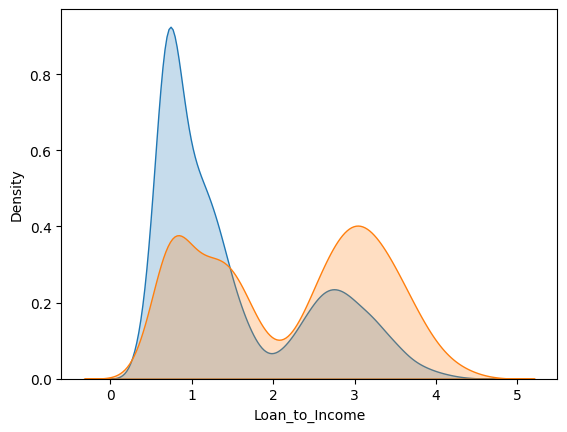

In [307]:
sns.kdeplot(df_train[df_train.default == 0]['Loan_to_Income'], fill=True, label="default-0")
sns.kdeplot(df_train[df_train.default == 1]['Loan_to_Income'], fill=True, label="default-1")

In [308]:
df_train['delinquency_ratio']=(df_train['delinquent_months']*100/df_train['total_loan_months']).round(2)
df_test['delinquency_ratio']=(df_test['delinquent_months']*100/df_test['total_loan_months']).round(2)

C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\2813056683.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['delinquency_ratio']=(df_train['delinquent_months']*100/df_train['total_loan_months']).round(2)
C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\2813056683.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['delinquency_ratio']=(df_test['delinquent_months']*100/df_test['total_loan_months']).round(2)


In [309]:
df_train[df_train['delinquency_ratio']==0].shape

(15088, 35)

In [310]:
df_train['avg_dpd_per_delinquent_months']=np.where(df_train['delinquent_months']!=0,df_train['total_dpd']/df_train['delinquent_months'],0)
df_test['avg_dpd_per_delinquent_months']=np.where(df_test['delinquent_months']!=0,df_test['total_dpd']/df_test['delinquent_months'],0)


C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\3272472925.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['avg_dpd_per_delinquent_months']=np.where(df_train['delinquent_months']!=0,df_train['total_dpd']/df_train['delinquent_months'],0)
C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\3272472925.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['avg_dpd_per_delinquent_months']=np.where(df_test['delinquent_months']!=0,df_test['total_dpd']/df_test['delinquent_months'],0)


In [311]:
df_test

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months
19205,C19206,36,M,Married,Self-Employed,3728000,3,Owned,24,Jaipur,Rajasthan,302001,2,1,42,0,0,5,98,L19206,None,Secured,12767000,9890000,197800.0,1780200,7912000,46,1745379,806208,2021-06-24,2021-07-23,0,2.652897,0.00,0.000000
15514,C15515,43,F,Single,Self-Employed,2493000,0,Owned,23,Delhi,Delhi,110001,4,0,125,0,0,5,32,L15515,None,Secured,4295000,3087000,61740.0,555660,2469600,18,1675530,1019647,2021-02-09,2021-02-18,0,1.238267,0.00,0.000000
30367,C30368,30,M,Married,Self-Employed,3114000,4,Owned,27,Delhi,Delhi,110001,3,0,76,0,0,6,82,L30368,None,Secured,4486000,3323000,66460.0,598140,2658400,35,1613282,1000932,2022-08-06,2022-08-21,0,1.067116,0.00,0.000000
35347,C35348,37,F,Single,Salaried,570000,2,Owned,5,Pune,Maharashtra,411001,4,2,125,3,21,7,48,L35348,None,Secured,2038000,1559000,31180.0,280620,1247200,46,398614,167679,2023-02-03,2023-02-04,0,2.735088,2.40,7.000000
41814,C41815,48,F,Single,Salaried,662000,0,Mortgage,23,Chennai,Tamil Nadu,600001,3,1,131,14,89,8,97,L41815,None,Secured,1880000,1351000,27020.0,243180,1080800,44,383925,262180,2023-09-27,2023-10-17,1,2.040785,10.69,6.357143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,C29298,27,M,Single,Self-Employed,185000,0,Owned,3,Jaipur,Rajasthan,302001,3,0,104,5,14,8,52,L29298,None,Secured,265000,253000,5060.0,45540,202400,29,96645,65285,2022-06-28,2022-06-30,0,1.367568,4.81,2.800000
20567,C20568,40,M,Single,Self-Employed,430000,0,Rented,19,Kolkata,West Bengal,700001,1,1,10,0,0,5,5,L20568,None,Secured,1458000,1363000,27260.0,245340,1090400,35,273282,158171,2021-08-13,2021-08-23,0,3.169767,0.00,0.000000
681,C00682,28,M,Married,Self-Employed,11961000,5,Rented,15,Bangalore,Karnataka,560001,2,2,32,2,7,4,54,L00682,None,Unsecured,5000000,3660000,73200.0,658800,2928000,15,2635199,4652930,2019-08-18,2019-09-16,0,0.305994,6.25,3.500000
33682,C33683,31,M,Single,Salaried,3430000,1,Owned,29,Delhi,Delhi,110001,1,0,36,0,0,4,85,L33683,None,Secured,13849000,12534000,250680.0,2256120,10027200,37,1907851,1029321,2022-12-05,2022-12-17,0,3.654227,0.00,0.000000


<Axes: xlabel='avg_dpd_per_delinquent_months', ylabel='Density'>

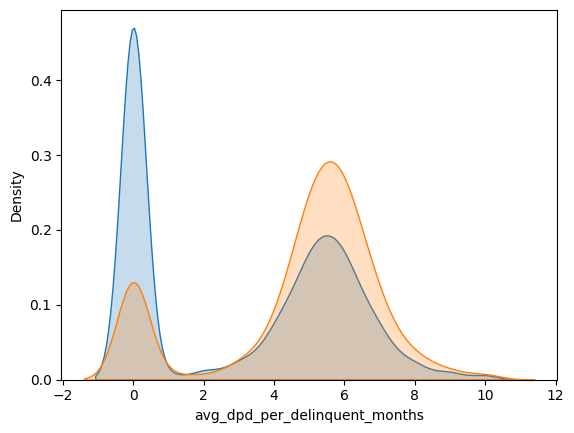

In [312]:
sns.kdeplot(df_train[df_train.default == 0]['avg_dpd_per_delinquent_months'], fill=True, label="default-0")
sns.kdeplot(df_train[df_train.default == 1]['avg_dpd_per_delinquent_months'], fill=True, label="default-1")

**Feature Engineering**

In [313]:
# Remove on the basis of technical knowledge
df_train_1=df_train.drop(columns={'cust_id','loan_id'},axis='columns')
df_test_1=df_test.drop(columns={'cust_id','loan_id'},axis='columns')

In [314]:
df_test_1.drop(columns={'disbursal_date','installment_start_dt','loan_amount','income','total_loan_months','delinquent_months','total_dpd'},axis='columns')
df_train_1.drop(columns={'disbursal_date','installment_start_dt','loan_amount','income','total_loan_months','delinquent_months','total_dpd'},axis='columns')

df_train_1.columns

Index(['age', 'gender', 'marital_status', 'employment_status', 'income',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'default', 'Loan_to_Income',
       'delinquency_ratio', 'avg_dpd_per_delinquent_months'],
      dtype='object')

In [315]:
df_test_1

,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months
19205,36,M,Married,Self-Employed,3728000,3,Owned,24,Jaipur,Rajasthan,302001,2,1,42,0,0,5,98,None,Secured,12767000,9890000,197800.0,1780200,7912000,46,1745379,806208,2021-06-24,2021-07-23,0,2.652897,0.00,0.000000
15514,43,F,Single,Self-Employed,2493000,0,Owned,23,Delhi,Delhi,110001,4,0,125,0,0,5,32,None,Secured,4295000,3087000,61740.0,555660,2469600,18,1675530,1019647,2021-02-09,2021-02-18,0,1.238267,0.00,0.000000
30367,30,M,Married,Self-Employed,3114000,4,Owned,27,Delhi,Delhi,110001,3,0,76,0,0,6,82,None,Secured,4486000,3323000,66460.0,598140,2658400,35,1613282,1000932,2022-08-06,2022-08-21,0,1.067116,0.00,0.000000
35347,37,F,Single,Salaried,570000,2,Owned,5,Pune,Maharashtra,411001,4,2,125,3,21,7,48,None,Secured,2038000,1559000,31180.0,280620,1247200,46,398614,167679,2023-02-03,2023-02-04,0,2.735088,2.40,7.000000
41814,48,F,Single,Salaried,662000,0,Mortgage,23,Chennai,Tamil Nadu,600001,3,1,131,14,89,8,97,None,Secured,1880000,1351000,27020.0,243180,1080800,44,383925,262180,2023-09-27,2023-10-17,1,2.040785,10.69,6.357143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,27,M,Single,Self-Employed,185000,0,Owned,3,Jaipur,Rajasthan,302001,3,0,104,5,14,8,52,None,Secured,265000,253000,5060.0,45540,202400,29,96645,65285,2022-06-28,2022-06-30,0,1.367568,4.81,2.800000
20567,40,M,Single,Self-Employed,430000,0,Rented,19,Kolkata,West Bengal,700001,1,1,10,0,0,5,5,None,Secured,1458000,1363000,27260.0,245340,1090400,35,273282,158171,2021-08-13,2021-08-23,0,3.169767,0.00,0.000000
681,28,M,Married,Self-Employed,11961000,5,Rented,15,Bangalore,Karnataka,560001,2,2,32,2,7,4,54,None,Unsecured,5000000,3660000,73200.0,658800,2928000,15,2635199,4652930,2019-08-18,2019-09-16,0,0.305994,6.25,3.500000
33682,31,M,Single,Salaried,3430000,1,Owned,29,Delhi,Delhi,110001,1,0,36,0,0,4,85,None,Secured,13849000,12534000,250680.0,2256120,10027200,37,1907851,1029321,2022-12-05,2022-12-17,0,3.654227,0.00,0.000000


In [316]:
df_train_1.select_dtypes(['float64','int64']).columns

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application', 'default',
       'Loan_to_Income', 'delinquency_ratio', 'avg_dpd_per_delinquent_months'],
      dtype='object')

In [317]:
x_train=df_train_1.drop(columns={'default'})
y_train=df_train_1['default']


In [318]:
cols_to_scale=x_train.select_dtypes(['int64','float64']).columns

In [319]:
cols_to_scale

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'Loan_to_Income', 'delinquency_ratio', 'avg_dpd_per_delinquent_months'],
      dtype='object')

In [320]:
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()
x_train[cols_to_scale]=scalar.fit_transform(x_train[cols_to_scale])


In [321]:
x_train.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months
count,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.00000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000
mean,0.414240,0.212934,0.388903,0.499918,0.523517,0.500925,0.50056,0.338317,0.201843,0.155961,0.501077,0.438653,0.088840,0.082513,0.082513,0.082513,0.082513,0.376631,0.261615,0.123550,0.294964,0.103300,0.328418
std,0.189590,0.220500,0.307182,0.297364,0.286491,0.373040,0.40701,0.197166,0.243374,0.191678,0.253666,0.296902,0.120117,0.112480,0.112480,0.112480,0.112480,0.234860,0.244461,0.133275,0.228177,0.172983,0.290674
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.058997,0.000000,0.233333,0.325424,0.000000,0.00000,0.184685,0.000000,0.000000,0.375000,0.181818,0.020555,0.018963,0.018963,0.018963,0.018963,0.188679,0.077988,0.034205,0.110257,0.000000,0.000000
50%,0.403846,0.150055,0.400000,0.500000,0.491525,0.666667,0.50000,0.315315,0.125000,0.076023,0.500000,0.393939,0.049364,0.045516,0.045516,0.045516,0.045516,0.339623,0.193870,0.082515,0.201941,0.036800,0.433333
75%,0.538462,0.271199,0.600000,0.766667,0.762712,1.000000,1.00000,0.477477,0.333333,0.269006,0.625000,0.676768,0.098027,0.095555,0.095555,0.095555,0.095555,0.547170,0.352418,0.155192,0.506913,0.129500,0.574185
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [322]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df['columns']=data.columns
    vif_df['VIF']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [323]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [324]:
calculate_vif(x_train[cols_to_scale])

C:\Users\Nandan\AppData\Roaming\Python\Python314\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,columns,VIF
0,age,5.801677
1,income,35.464831
2,number_of_dependants,2.734262
3,years_at_current_address,3.455147
4,zipcode,3.843805
5,number_of_open_accounts,8.237241
6,number_of_closed_accounts,2.394505
7,total_loan_months,10.500613
8,delinquent_months,49.345214
9,total_dpd,51.326917


In [325]:
features_to_drop=['income','delinquent_months','total_dpd','sanction_amount','loan_amount','processing_fee','gst','net_disbursement','principal_outstanding','total_loan_months']

In [326]:
x_train1=x_train.drop(columns=features_to_drop)

In [327]:
numeric_cols=x_train1.select_dtypes(['int64','float64']).columns

In [328]:
vif_df=calculate_vif(x_train1[numeric_cols])
vif_df

,columns,VIF
0,age,5.428847
1,number_of_dependants,2.726782
2,years_at_current_address,3.403800
3,zipcode,3.777997
4,number_of_open_accounts,4.353486
5,number_of_closed_accounts,2.372476
6,enquiry_count,6.384190
7,credit_utilization_ratio,2.919877
8,loan_tenure_months,6.019275
9,bank_balance_at_application,1.804690


In [329]:
selected_numeric_features_vif=vif_df['columns']
selected_numeric_features_vif

0                               age
1              number_of_dependants
2          years_at_current_address
3                           zipcode
4           number_of_open_accounts
5         number_of_closed_accounts
6                     enquiry_count
7          credit_utilization_ratio
8                loan_tenure_months
9       bank_balance_at_application
10                   Loan_to_Income
11                delinquency_ratio
12    avg_dpd_per_delinquent_months
Name: columns, dtype: object

In [330]:
x_train1

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_purpose,loan_type,loan_tenure_months,bank_balance_at_application,disbursal_date,installment_start_dt,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months
12746,0.788462,M,Married,Self-Employed,0.6,Owned,0.966667,Hyderabad,Telangana,0.661017,1.000000,1.0,0.375,0.363636,None,Secured,0.415094,0.613386,2020-10-31,2020-11-11,0.415154,0.1316,0.590000
32495,0.500000,F,Single,Salaried,0.0,Owned,0.866667,Mumbai,Maharashtra,0.491525,0.666667,0.5,0.500,0.050505,None,Secured,0.830189,0.025205,2022-10-22,2022-10-27,0.306751,0.0625,0.620000
43675,0.384615,M,Single,Salaried,0.0,Mortgage,0.833333,Chennai,Tamil Nadu,0.830508,0.000000,0.5,0.375,0.000000,None,Secured,0.490566,0.174318,2023-12-04,2023-12-29,0.758695,0.2222,0.558333
9040,0.461538,M,Married,Salaried,0.4,Mortgage,0.966667,Bangalore,Karnataka,0.762712,0.666667,0.0,0.875,0.878788,None,Secured,0.641509,0.077523,2020-06-18,2020-07-07,0.194969,0.0000,0.000000
13077,0.769231,M,Married,Self-Employed,0.8,Owned,0.933333,Pune,Maharashtra,0.510169,0.000000,1.0,0.000,0.717172,None,Unsecured,0.169811,0.072271,2020-11-12,2020-12-07,0.046880,0.0000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,1.000000,M,Single,Self-Employed,0.0,Owned,0.633333,Kolkata,West Bengal,1.000000,0.333333,0.0,0.500,0.131313,None,Unsecured,0.113208,0.061603,2022-05-30,2022-06-09,0.064884,0.0000,0.000000
5558,0.403846,F,Single,Salaried,0.0,Rented,0.833333,Kolkata,West Bengal,1.000000,0.000000,0.0,0.375,0.444444,None,Secured,0.490566,0.072569,2020-02-12,2020-02-17,0.191143,0.2692,0.514286
45236,0.403846,M,Married,Self-Employed,0.8,Owned,0.300000,Pune,Maharashtra,0.510169,1.000000,1.0,0.625,0.979798,None,Secured,0.603774,0.063574,2024-01-30,2024-02-04,0.719953,0.0846,0.400000
49228,0.288462,M,Single,Salaried,0.4,Owned,0.833333,Chennai,Tamil Nadu,0.830508,0.333333,0.5,0.625,0.252525,None,Secured,0.584906,0.058224,2024-06-24,2024-07-21,0.277815,0.0000,0.000000


In [331]:
df_train_1.drop(columns=features_to_drop,inplace=True)

In [332]:
df_train_1

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_purpose,loan_type,loan_tenure_months,bank_balance_at_application,disbursal_date,installment_start_dt,default,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months
12746,59,M,Married,Self-Employed,3,Owned,30,Hyderabad,Telangana,500001,4,2,4,36,None,Secured,28,4820526,2020-10-31,2020-11-11,0,2.069568,13.16,5.900000
32495,44,F,Single,Salaried,0,Owned,27,Mumbai,Maharashtra,400001,3,1,5,5,None,Secured,50,216697,2022-10-22,2022-10-27,0,1.606993,6.25,6.200000
43675,38,M,Single,Salaried,0,Mortgage,26,Chennai,Tamil Nadu,600001,1,1,4,0,None,Secured,32,1383842,2023-12-04,2023-12-29,0,3.535524,22.22,5.583333
9040,42,M,Married,Salaried,2,Mortgage,30,Bangalore,Karnataka,560001,3,0,8,87,None,Secured,40,626203,2020-06-18,2020-07-07,0,1.130000,0.00,0.000000
13077,58,M,Married,Self-Employed,4,Owned,29,Pune,Maharashtra,411001,1,2,1,71,None,Unsecured,15,585099,2020-11-12,2020-12-07,0,0.498074,0.00,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,70,M,Single,Self-Employed,0,Owned,20,Kolkata,West Bengal,700001,2,0,5,13,None,Unsecured,12,501594,2022-05-30,2022-06-09,0,0.574899,0.00,0.000000
5558,39,F,Single,Salaried,0,Rented,26,Kolkata,West Bengal,700001,1,0,4,44,None,Secured,32,587429,2020-02-12,2020-02-17,0,1.113673,26.92,5.142857
45236,39,M,Married,Self-Employed,4,Owned,10,Pune,Maharashtra,411001,4,2,6,97,None,Secured,38,517025,2024-01-30,2024-02-04,1,3.370203,8.46,4.000000
49228,33,M,Single,Salaried,2,Owned,26,Chennai,Tamil Nadu,600001,2,1,6,25,None,Secured,37,475147,2024-06-24,2024-07-21,0,1.483516,0.00,0.000000


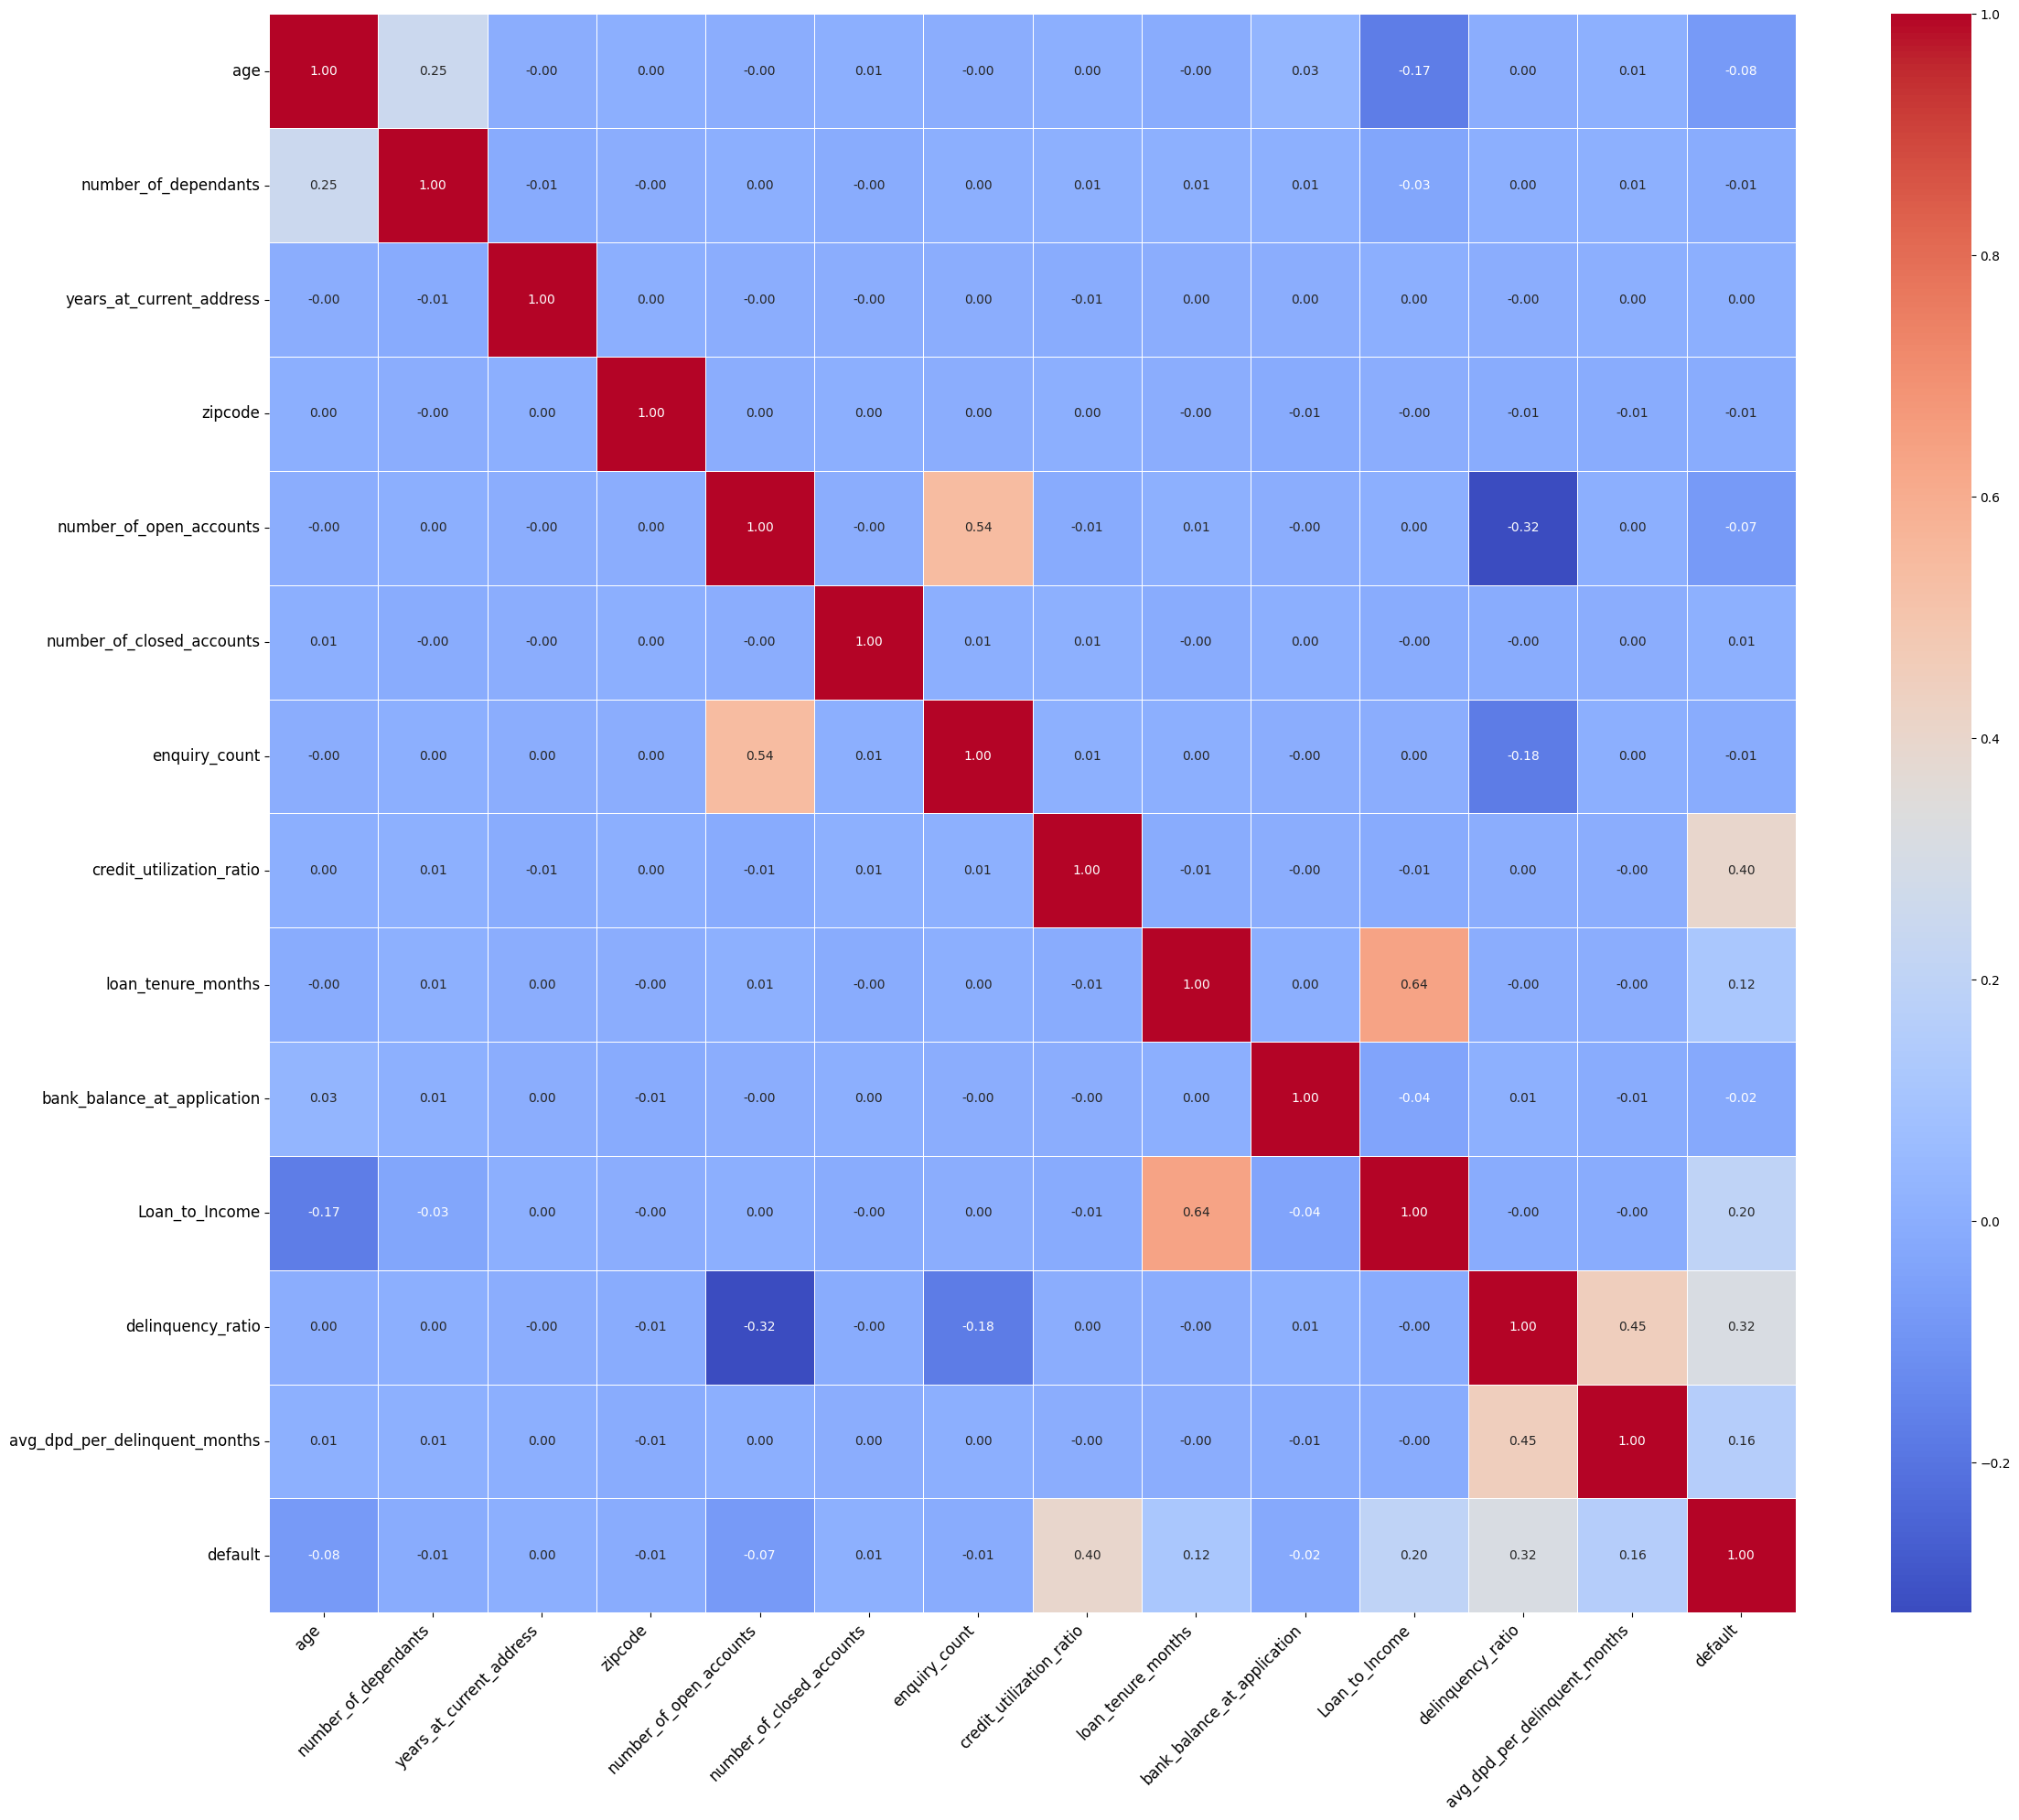

In [333]:
plt.figure(figsize=(24,20))  # bigger figure

cm = df_train_1[numeric_cols.append(pd.Index(['default']))].corr()

sns.heatmap(
    cm,
    annot=True,          # show numbers
    fmt=".2f",
    cmap="coolwarm",     # clearer color scale
    annot_kws={"size":10},  # number font size
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.show()

In [334]:
x_train1.drop(columns={"disbursal_date","installment_start_dt"},inplace=True)

In [335]:
categorical_cols=x_train1.select_dtypes(include=['object','category']).columns
categorical_cols

Index(['gender', 'marital_status', 'employment_status', 'residence_type',
       'city', 'state', 'loan_purpose', 'loan_type'],
      dtype='object')

In [336]:
categorical_cols

Index(['gender', 'marital_status', 'employment_status', 'residence_type',
       'city', 'state', 'loan_purpose', 'loan_type'],
      dtype='object')

In [337]:
temp=pd.concat([x_train1[categorical_cols],y_train],axis='columns')
temp

,gender,marital_status,employment_status,residence_type,city,state,loan_purpose,loan_type,default
12746,M,Married,Self-Employed,Owned,Hyderabad,Telangana,None,Secured,0
32495,F,Single,Salaried,Owned,Mumbai,Maharashtra,None,Secured,0
43675,M,Single,Salaried,Mortgage,Chennai,Tamil Nadu,None,Secured,0
9040,M,Married,Salaried,Mortgage,Bangalore,Karnataka,None,Secured,0
13077,M,Married,Self-Employed,Owned,Pune,Maharashtra,None,Unsecured,0
...,...,...,...,...,...,...,...,...,...
28515,M,Single,Self-Employed,Owned,Kolkata,West Bengal,None,Unsecured,0
5558,F,Single,Salaried,Rented,Kolkata,West Bengal,None,Secured,0
45236,M,Married,Self-Employed,Owned,Pune,Maharashtra,None,Secured,1
49228,M,Single,Salaried,Owned,Chennai,Tamil Nadu,None,Secured,0


In [338]:
temp.groupby(['loan_purpose','default']).agg(['count'])

,,gender,marital_status,employment_status,residence_type,city,state,loan_type
,,count,count,count,count,count,count,count
loan_purpose,default,,,,,,,


In [339]:
def calculate_woe_IV(df, feature, target):
    
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns={'count':'total','sum':'good'})
    
    # bad = total - good
    grouped['bad'] = grouped['total'] - grouped['good']

    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad

    grouped['woe'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
    grouped['iv'] = (grouped['good_pct'] - grouped['bad_pct']) * grouped['woe']

    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)

    total_iv = grouped['iv'].sum()

    return grouped, total_iv


grouped, total_iv = calculate_woe_IV(temp, 'loan_purpose', 'default')

In [340]:
grouped

,total,good,bad,good_pct,bad_pct,woe,iv
loan_purpose,,,,,,,


In [341]:
x_train1

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_purpose,loan_type,loan_tenure_months,bank_balance_at_application,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months
12746,0.788462,M,Married,Self-Employed,0.6,Owned,0.966667,Hyderabad,Telangana,0.661017,1.000000,1.0,0.375,0.363636,None,Secured,0.415094,0.613386,0.415154,0.1316,0.590000
32495,0.500000,F,Single,Salaried,0.0,Owned,0.866667,Mumbai,Maharashtra,0.491525,0.666667,0.5,0.500,0.050505,None,Secured,0.830189,0.025205,0.306751,0.0625,0.620000
43675,0.384615,M,Single,Salaried,0.0,Mortgage,0.833333,Chennai,Tamil Nadu,0.830508,0.000000,0.5,0.375,0.000000,None,Secured,0.490566,0.174318,0.758695,0.2222,0.558333
9040,0.461538,M,Married,Salaried,0.4,Mortgage,0.966667,Bangalore,Karnataka,0.762712,0.666667,0.0,0.875,0.878788,None,Secured,0.641509,0.077523,0.194969,0.0000,0.000000
13077,0.769231,M,Married,Self-Employed,0.8,Owned,0.933333,Pune,Maharashtra,0.510169,0.000000,1.0,0.000,0.717172,None,Unsecured,0.169811,0.072271,0.046880,0.0000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,1.000000,M,Single,Self-Employed,0.0,Owned,0.633333,Kolkata,West Bengal,1.000000,0.333333,0.0,0.500,0.131313,None,Unsecured,0.113208,0.061603,0.064884,0.0000,0.000000
5558,0.403846,F,Single,Salaried,0.0,Rented,0.833333,Kolkata,West Bengal,1.000000,0.000000,0.0,0.375,0.444444,None,Secured,0.490566,0.072569,0.191143,0.2692,0.514286
45236,0.403846,M,Married,Self-Employed,0.8,Owned,0.300000,Pune,Maharashtra,0.510169,1.000000,1.0,0.625,0.979798,None,Secured,0.603774,0.063574,0.719953,0.0846,0.400000
49228,0.288462,M,Single,Salaried,0.4,Owned,0.833333,Chennai,Tamil Nadu,0.830508,0.333333,0.5,0.625,0.252525,None,Secured,0.584906,0.058224,0.277815,0.0000,0.000000


In [342]:
from pandas.api.types import is_numeric_dtype

iv_values = {}

data = pd.concat([x_train1, y_train], axis=1)

for feature in x_train1.columns:

    if is_numeric_dtype(data[feature]):
        data_temp = data.copy()
        data_temp[feature] = pd.cut(data_temp[feature], bins=10)
        _, iv = calculate_woe_IV(data_temp, feature, 'default')
    else:
        _, iv = calculate_woe_IV(data, feature, 'default')

    iv_values[feature] = iv

iv_values

C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\3313434850.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count','sum'])
C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\3313434850.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(feature)[target].agg(['count','sum'])
C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\3313434850.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

{'age': np.float64(0.0890689462679479),
 'gender': np.float64(0.00047449502170914947),
 'marital_status': np.float64(0.001129766845390142),
 'employment_status': np.float64(0.003953046301722585),
 'number_of_dependants': np.float64(0.001938089913505351),
 'residence_type': np.float64(0.246745268718145),
 'years_at_current_address': np.float64(0.0020800513608156363),
 'city': np.float64(0.0019059578709781529),
 'state': np.float64(0.0019005589806779287),
 'zipcode': np.float64(0.0016677413243392572),
 'number_of_open_accounts': np.float64(0.08463134083005877),
 'number_of_closed_accounts': np.float64(0.0011964272592421567),
 'enquiry_count': np.float64(0.007864214085342608),
 'credit_utilization_ratio': np.float64(2.352965568168245),
 'loan_purpose': np.float64(0.0),
 'loan_type': np.float64(0.16319324904149224),
 'loan_tenure_months': np.float64(0.21893515090196278),
 'bank_balance_at_application': np.float64(0.0063187993277516365),
 'Loan_to_Income': np.float64(0.47572195076776647),
 

In [343]:
iv_df=pd.DataFrame(list(iv_values.items()), columns=['feature','IV'])
iv_df=iv_df.sort_values(by='IV', ascending=False)
iv_df

,feature,IV
13,credit_utilization_ratio,2.352966
19,delinquency_ratio,0.716576
18,Loan_to_Income,0.475722
20,avg_dpd_per_delinquent_months,0.401766
5,residence_type,0.246745
16,loan_tenure_months,0.218935
15,loan_type,0.163193
0,age,0.089069
10,number_of_open_accounts,0.084631
12,enquiry_count,0.007864


In [344]:
selected_feature=[feature for feature, iv in iv_values.items() if iv > 0.02]
selected_feature

['age',
 'residence_type',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_type',
 'loan_tenure_months',
 'Loan_to_Income',
 'delinquency_ratio',
 'avg_dpd_per_delinquent_months']

In [345]:
y_test=df_test_1['default']

In [346]:
df_test_1['default']

19205    0
15514    0
30367    0
35347    0
41814    1
        ..
29297    0
20567    0
681      0
33682    0
26116    0
Name: default, Length: 12497, dtype: int64

**Feature Encoding**


In [347]:
x_train_reduced=x_train1[selected_feature]
x_test_reduced=df_test_1[selected_feature]

In [348]:
x_test_reduced.shape

(12497, 9)

In [349]:
x_train_reduced.head(3)

,age,residence_type,number_of_open_accounts,credit_utilization_ratio,loan_type,loan_tenure_months,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months
12746,0.788462,Owned,1.000000,0.363636,Secured,0.415094,0.415154,0.1316,0.590000
32495,0.500000,Owned,0.666667,0.050505,Secured,0.830189,0.306751,0.0625,0.620000
43675,0.384615,Mortgage,0.000000,0.000000,Secured,0.490566,0.758695,0.2222,0.558333


In [350]:
x_train_encoded=pd.get_dummies(x_train_reduced, drop_first=True)
x_test_reduced

,age,residence_type,number_of_open_accounts,credit_utilization_ratio,loan_type,loan_tenure_months,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months
19205,36,Owned,2,98,Secured,46,2.652897,0.00,0.000000
15514,43,Owned,4,32,Secured,18,1.238267,0.00,0.000000
30367,30,Owned,3,82,Secured,35,1.067116,0.00,0.000000
35347,37,Owned,4,48,Secured,46,2.735088,2.40,7.000000
41814,48,Mortgage,3,97,Secured,44,2.040785,10.69,6.357143
...,...,...,...,...,...,...,...,...,...
29297,27,Owned,3,52,Secured,29,1.367568,4.81,2.800000
20567,40,Rented,1,5,Secured,35,3.169767,0.00,0.000000
681,28,Rented,2,54,Unsecured,15,0.305994,6.25,3.500000
33682,31,Owned,1,85,Secured,37,3.654227,0.00,0.000000


In [351]:
x_train_encoded

,age,number_of_open_accounts,credit_utilization_ratio,loan_tenure_months,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
12746,0.788462,1.000000,0.363636,0.415094,0.415154,0.1316,0.590000,True,False,False
32495,0.500000,0.666667,0.050505,0.830189,0.306751,0.0625,0.620000,True,False,False
43675,0.384615,0.000000,0.000000,0.490566,0.758695,0.2222,0.558333,False,False,False
9040,0.461538,0.666667,0.878788,0.641509,0.194969,0.0000,0.000000,False,False,False
13077,0.769231,0.000000,0.717172,0.169811,0.046880,0.0000,0.000000,True,False,True
...,...,...,...,...,...,...,...,...,...,...
28515,1.000000,0.333333,0.131313,0.113208,0.064884,0.0000,0.000000,True,False,True
5558,0.403846,0.000000,0.444444,0.490566,0.191143,0.2692,0.514286,False,True,False
45236,0.403846,1.000000,0.979798,0.603774,0.719953,0.0846,0.400000,True,False,False
49228,0.288462,0.333333,0.252525,0.584906,0.277815,0.0000,0.000000,True,False,False


In [352]:
x_test_reduced

,age,residence_type,number_of_open_accounts,credit_utilization_ratio,loan_type,loan_tenure_months,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months
19205,36,Owned,2,98,Secured,46,2.652897,0.00,0.000000
15514,43,Owned,4,32,Secured,18,1.238267,0.00,0.000000
30367,30,Owned,3,82,Secured,35,1.067116,0.00,0.000000
35347,37,Owned,4,48,Secured,46,2.735088,2.40,7.000000
41814,48,Mortgage,3,97,Secured,44,2.040785,10.69,6.357143
...,...,...,...,...,...,...,...,...,...
29297,27,Owned,3,52,Secured,29,1.367568,4.81,2.800000
20567,40,Rented,1,5,Secured,35,3.169767,0.00,0.000000
681,28,Rented,2,54,Unsecured,15,0.305994,6.25,3.500000
33682,31,Owned,1,85,Secured,37,3.654227,0.00,0.000000


In [353]:
num_cols1 = x_test_reduced.select_dtypes(include=['number']).columns
num_cols1

Index(['age', 'number_of_open_accounts', 'credit_utilization_ratio',
       'loan_tenure_months', 'Loan_to_Income', 'delinquency_ratio',
       'avg_dpd_per_delinquent_months'],
      dtype='object')

In [354]:
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()
x_test_reduced[num_cols1]=scalar.fit_transform(x_test_reduced[num_cols1])
x_test_reduced.shape

C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\1292848362.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_test_reduced[num_cols1]=scalar.fit_transform(x_test_reduced[num_cols1])


(12497, 9)

In [355]:
x_test_encoded=pd.get_dummies(x_test_reduced, drop_first=True)
x_test_encoded

,age,number_of_open_accounts,credit_utilization_ratio,loan_tenure_months,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
19205,0.346154,0.333333,0.989899,0.754717,0.548701,0.0000,0.000000,True,False,False
15514,0.480769,1.000000,0.323232,0.226415,0.219342,0.0000,0.000000,True,False,False
30367,0.230769,0.666667,0.828283,0.547170,0.179494,0.0000,0.000000,True,False,False
35347,0.365385,1.000000,0.484848,0.754717,0.567837,0.0240,0.700000,True,False,False
41814,0.576923,0.666667,0.979798,0.716981,0.406187,0.1069,0.635714,False,False,False
...,...,...,...,...,...,...,...,...,...,...
29297,0.173077,0.666667,0.525253,0.433962,0.249447,0.0481,0.280000,True,False,False
20567,0.423077,0.000000,0.050505,0.547170,0.669041,0.0000,0.000000,False,True,False
681,0.192308,0.333333,0.545455,0.169811,0.002287,0.0625,0.350000,False,True,True
33682,0.250000,0.000000,0.858586,0.584906,0.781835,0.0000,0.000000,True,False,False


In [356]:
x_train_encoded.shape

(37488, 10)

In [357]:
x_test_encoded.shape

(12497, 10)

In [358]:
y_test.shape

(12497,)

## Model Traning ##

**Atempt-1**

Logistics regression


In [359]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
lr=LogisticRegression()
lr.fit(x_train_encoded,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [360]:
y_predict1=lr.predict(x_test_encoded)
y_predict1.shape

(12497,)

In [361]:
x_test_encoded.shape


(12497, 10)

In [362]:
report=classification_report(y_test,y_predict1)

In [363]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_predict1)
accuracy

0.9631911658798111

In [364]:
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.84      0.71      0.77      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.87     12497
weighted avg       0.96      0.96      0.96     12497



In [365]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model=RandomForestClassifier()
model.fit(x_train_encoded,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [366]:
y_predict=model.predict(x_test_encoded)
report=classification_report(y_test,y_predict)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.97     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.97      0.96     12497



In [367]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_predict)
accuracy

0.9650316075858206

In [368]:
from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(x_train_encoded,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [369]:
y_predict2=model.predict(x_test_encoded)
from sklearn.metrics import classification_report
report=classification_report(y_test,y_predict2)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.82      0.76      0.79      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.87      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [370]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_predict2)
accuracy

0.9647915499719932

In [371]:
! pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [372]:
y_train.value_counts()

default
0    34265
1     3223
Name: count, dtype: int64

In [373]:
y_test.value_counts()

default
0    11423
1     1074
Name: count, dtype: int64

In [374]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
# Define parameter distribution for RandomSearchCV

param_dis={
    'n_estimators': [100,150,200,250,300],
    'max_depth': [3,4,5,6,7,8,9,10],
    'learning_rate':[0.01,0.03,0.05,0.1,0.15,0.2,0.25,0.3],
    'subsample':[0.6,0.7,0.8,0.9,1],
    'colsample_bytree': [0.6,0.7,0.8,0.9,1],
    'scale_pos_weight':[1,2,3,5,7,10],
    'reg_alpha':[0.01,0.1,0.5,1.0,5.0,10.0],
    'reg_lambda':[0.01,0.1,0.5,1.0,5.0,10.0]
}

xgb=XGBClassifier()

random_search=RandomizedSearchCV(estimator=xgb,param_distributions=param_dis, n_iter=100, scoring='f1', cv=3, verbose=1, n_jobs=-1,random_state=42)
 
random_search.fit(x_train_encoded,y_train)

# print the best parameters and best score
print(f"best parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model=random_search.best_estimator_
y_pred_=best_model.predict(x_test_encoded)
print("classification_report : ")
print(classification_report(y_test,y_pred_))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
best parameters: {'subsample': 0.8, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 5.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best Score: 0.7876443163003897
classification_report : 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.77      0.83      0.80      1074

    accuracy                           0.96     12497
   macro avg       0.88      0.90      0.89     12497
weighted avg       0.97      0.96      0.96     12497



In [375]:
from imblearn.under_sampling import RandomUnderSampler

rus=RandomUnderSampler(random_state=42)
x_train_rus, y_train_rus = rus.fit_resample(x_train_encoded,y_train)
y_train_rus.value_counts()

default
0    3223
1    3223
Name: count, dtype: int64

In [376]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [377]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,accuracy_score
model=LogisticRegression()
model.fit(x_train_rus,y_train_rus)
y_pred_3=model.predict(x_test_encoded)

In [378]:
report=classification_report(y_test,y_pred_3)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.91      0.95     11423
           1       0.50      0.95      0.65      1074

    accuracy                           0.91     12497
   macro avg       0.75      0.93      0.80     12497
weighted avg       0.95      0.91      0.92     12497



In [379]:
from xgboost import XGBClassifier
model=XGBClassifier(**random_search.best_params_)
model.fit(x_train_rus,y_train_rus)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [380]:
y_predict2=model.predict(x_test_encoded)
from sklearn.metrics import classification_report
report=classification_report(y_test,y_predict2)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.52      0.99      0.68      1074

    accuracy                           0.92     12497
   macro avg       0.76      0.95      0.82     12497
weighted avg       0.96      0.92      0.93     12497



OverSampling

In [381]:
from imblearn.combine import SMOTETomek

smt=SMOTETomek(random_state=42)
x_train_smt, y_train_smt= smt.fit_resample(x_train_encoded, y_train)
y_train_smt.value_counts()

default
0    34199
1    34199
Name: count, dtype: int64

In [382]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
model=LogisticRegression()
model.fit(x_train_smt,y_train_smt)
y_pred=model.predict(x_test_encoded)
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.92      0.96     11423
           1       0.53      0.94      0.68      1074

    accuracy                           0.92     12497
   macro avg       0.76      0.93      0.82     12497
weighted avg       0.95      0.92      0.93     12497



In [383]:
! pip install optuna

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [384]:
import optuna
from sklearn.model_selection import cross_val_score

C:\Users\Nandan\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [385]:
from sklearn.linear_model import LogisticRegression

In [386]:
import optuna
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

def objective(trial):

    C = trial.suggest_float("C", 1, 5)
    solver = trial.suggest_categorical("solver",
                                       ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'])

    model = LogisticRegression(C=C, solver=solver, max_iter=1000)

    scores = cross_val_score(model, x_train_encoded, y_train, cv=3, scoring="accuracy")

    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("Best parameters:", study.best_params)
print("Best cross-validation accuracy:", study.best_value)

[I 2026-03-10 19:35:18,544] A new study created in memory with name: no-name-7e5a8e0a-1414-4539-b79c-d24cad2fc52a
[I 2026-03-10 19:35:18,906] Trial 0 finished with value: 0.959053563807085 and parameters: {'C': 4.3082957238377855, 'solver': 'liblinear'}. Best is trial 0 with value: 0.959053563807085.
[I 2026-03-10 19:35:19,072] Trial 1 finished with value: 0.9590268886043534 and parameters: {'C': 1.6438079926962805, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.959053563807085.
[I 2026-03-10 19:35:20,001] Trial 2 finished with value: 0.9593203158344004 and parameters: {'C': 4.5440002648907, 'solver': 'saga'}. Best is trial 2 with value: 0.9593203158344004.
[I 2026-03-10 19:35:20,331] Trial 3 finished with value: 0.959053563807085 and parameters: {'C': 4.286350735960076, 'solver': 'liblinear'}. Best is trial 2 with value: 0.9593203158344004.
[I 2026-03-10 19:35:21,801] Trial 4 finished with value: 0.9592402902262057 and parameters: {'C': 3.711323974137623, 'solver': 'sag'}. Best is 

Best parameters: {'C': 4.5440002648907, 'solver': 'saga'}
Best cross-validation accuracy: 0.9593203158344004


In [387]:
best_model=LogisticRegression(**study.best_params, max_iter=2000)
best_model.fit(x_train_encoded,y_train)

y_pred4=best_model.predict(x_test_encoded)
report=classification_report(y_test,y_pred4)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.83      0.72      0.77      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [388]:
import optuna 
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

In [389]:
import optuna
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

# Objective function
def objective(trial):

    param = {
        "C": trial.suggest_float("C", 1e-4, 1e4, log=True),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "liblinear", "saga", "newton-cg"]),
        "tol": trial.suggest_float("tol", 1e-6, 1e-1, log=True),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"])
    }

    model = LogisticRegression(**param, max_iter=10000)

    # F1 scorer
    f1_scorer = make_scorer(f1_score, average="macro")

    scores = cross_val_score(
        model,
        x_train_smt,
        y_train_smt,
        cv=3,
        scoring=f1_scorer,
        n_jobs=-1
    )

    return np.mean(scores)


study_logistic = optuna.create_study(direction="maximize")

study_logistic.optimize(objective, n_trials=50)

print("Best parameters:", study_logistic.best_params)
print("Best F1 score:", study_logistic.best_value)

[I 2026-03-10 19:35:24,076] A new study created in memory with name: no-name-30dfb534-a434-4f2d-a62b-bf3681e0aa02
[I 2026-03-10 19:35:24,351] Trial 0 finished with value: 0.8023964205832973 and parameters: {'C': 13.809145960496231, 'solver': 'newton-cg', 'tol': 0.08468035501660949, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8023964205832973.
[I 2026-03-10 19:35:24,741] Trial 1 finished with value: 0.9398351090406528 and parameters: {'C': 539.2082833685154, 'solver': 'liblinear', 'tol': 0.0013696618243843812, 'class_weight': None}. Best is trial 1 with value: 0.9398351090406528.
[I 2026-03-10 19:35:25,088] Trial 2 finished with value: 0.9381193418208668 and parameters: {'C': 931.761741037865, 'solver': 'newton-cg', 'tol': 0.00642028596826479, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9398351090406528.
[I 2026-03-10 19:35:25,464] Trial 3 finished with value: 0.9398791134508785 and parameters: {'C': 1548.6268891937427, 'solver': 'lbfgs', 'tol': 2.026375055

Best parameters: {'C': 33.25215942738513, 'solver': 'lbfgs', 'tol': 7.534942143361095e-05, 'class_weight': 'balanced'}
Best F1 score: 0.9399376869876876


In [390]:
print("Best trial: ")
trial=study_logistic.best_trial
print("  F1-score: {}" .format(trial.value))
print('   params:  ')
for key, value in trial.params.items():
    print('     {}: {}'.format(key, value))

best_model_logistics=LogisticRegression(**study_logistic.best_params)
best_model_logistics.fit(x_train_smt, y_train_smt)

# Evaluate on the test set
y_pred5=best_model_logistics.predict(x_test_encoded)

report=classification_report(y_test,y_pred5)
print(report)

Best trial: 
  F1-score: 0.9399376869876876
   params:  
     C: 33.25215942738513
     solver: lbfgs
     tol: 7.534942143361095e-05
     class_weight: balanced
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     11423
           1       0.53      0.94      0.68      1074

    accuracy                           0.92     12497
   macro avg       0.76      0.93      0.82     12497
weighted avg       0.95      0.92      0.93     12497



Attempt 4
1. XGBOOST
2. Handle class imblance using smote tomek
3. parameter tunning using optuna

In [391]:
import optuna
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score


# Objective function
def objective(trial):

    param = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "verbosity": 0,
        "booster": "gbtree",

        "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),

        "subsample": trial.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),

        "max_depth": trial.suggest_int("max_depth", 3, 10),

        "eta": trial.suggest_float("eta", 0.01, 0.3),

        "gamma": trial.suggest_float("gamma", 0, 10),

        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1, 10),

        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10)
    }

    model = XGBClassifier(**param)

    # F1 scorer
    f1_scorer = make_scorer(f1_score, average="macro")

    scores = cross_val_score(
        model,
        x_train_smt,
        y_train_smt,
        cv=3,
        scoring=f1_scorer,
        n_jobs=-1
    )

    return np.mean(scores)


study_xgb = optuna.create_study(direction="maximize")

study_xgb.optimize(objective, n_trials=50)

print("Best parameters:", study_xgb.best_params)
print("Best F1 score:", study_xgb.best_value)

[I 2026-03-10 19:35:44,622] A new study created in memory with name: no-name-bbbd1f63-aa3c-4bb8-a258-78b9a1a7bd20
[I 2026-03-10 19:35:46,961] Trial 0 finished with value: 0.9604886029604062 and parameters: {'lambda': 0.0022551220027737756, 'alpha': 0.17987756194862153, 'subsample': 0.5147922616292614, 'colsample_bytree': 0.41813279686475574, 'max_depth': 8, 'eta': 0.22126154685926921, 'gamma': 8.014767329268583, 'scale_pos_weight': 5.7463333479892835, 'min_child_weight': 2, 'max_delta_step': 10}. Best is trial 0 with value: 0.9604886029604062.
[I 2026-03-10 19:35:49,736] Trial 1 finished with value: 0.9426988720071184 and parameters: {'lambda': 0.016506800198954518, 'alpha': 0.0018741454940231182, 'subsample': 0.4950820008527142, 'colsample_bytree': 0.8880751660722384, 'max_depth': 6, 'eta': 0.04381096951633206, 'gamma': 1.6769118441477848, 'scale_pos_weight': 8.376512485933986, 'min_child_weight': 1, 'max_delta_step': 4}. Best is trial 0 with value: 0.9604886029604062.
[I 2026-03-10 1

Best parameters: {'lambda': 0.14489133811099145, 'alpha': 0.0011443432746458383, 'subsample': 0.7543189918940834, 'colsample_bytree': 0.574811693434869, 'max_depth': 10, 'eta': 0.20944072725381996, 'gamma': 0.0924698084553632, 'scale_pos_weight': 1.0206728813605084, 'min_child_weight': 6, 'max_delta_step': 5}
Best F1 score: 0.9762526076229671


In [392]:
print("Best trial: ")
trial=study_xgb.best_trial
print("  F1-score: {}" .format(trial.value))
print('   params:  ')
for key, value in trial.params.items():
    print('     {}: {}'.format(key, value))

best_params=study_xgb.best_params
best_model_xgb=XGBClassifier(**best_params)
best_model_xgb.fit(x_train_smt, y_train_smt)

# Evaluate on the test set
y_pred6=best_model_logistics.predict(x_test_encoded)

report=classification_report(y_test,y_pred6)
print(report)

Best trial: 
  F1-score: 0.9762526076229671
   params:  
     lambda: 0.14489133811099145
     alpha: 0.0011443432746458383
     subsample: 0.7543189918940834
     colsample_bytree: 0.574811693434869
     max_depth: 10
     eta: 0.20944072725381996
     gamma: 0.0924698084553632
     scale_pos_weight: 1.0206728813605084
     min_child_weight: 6
     max_delta_step: 5
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     11423
           1       0.53      0.94      0.68      1074

    accuracy                           0.92     12497
   macro avg       0.76      0.93      0.82     12497
weighted avg       0.95      0.92      0.93     12497



In [393]:
best_model_logistics.predict(x_test_encoded)
report=classification_report(y_test,y_pred5)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.92      0.96     11423
           1       0.53      0.94      0.68      1074

    accuracy                           0.92     12497
   macro avg       0.76      0.93      0.82     12497
weighted avg       0.95      0.92      0.93     12497



In [394]:
from sklearn.metrics import roc_curve
probabilities=best_model_logistics.predict_proba(x_test_encoded)[:,1]
probabilities

fpr, tpr, thresholds= roc_curve(y_test, probabilities)
fpr[:10],tpr[:10], thresholds[:10]

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.75426771e-05,
        8.75426771e-05, 1.75085354e-04, 1.75085354e-04, 2.62628031e-04,
        2.62628031e-04, 3.50170708e-04]),
 array([0.        , 0.0009311 , 0.20949721, 0.20949721, 0.22067039,
        0.22067039, 0.23091248, 0.23091248, 0.25325885, 0.25325885]),
 array([       inf, 1.        , 0.99845446, 0.99842858, 0.99816037,
        0.99815869, 0.9979021 , 0.99789714, 0.99733176, 0.99731437]))

In [395]:
from sklearn.metrics import auc
area=auc(fpr, tpr)
area

0.9819101290463833

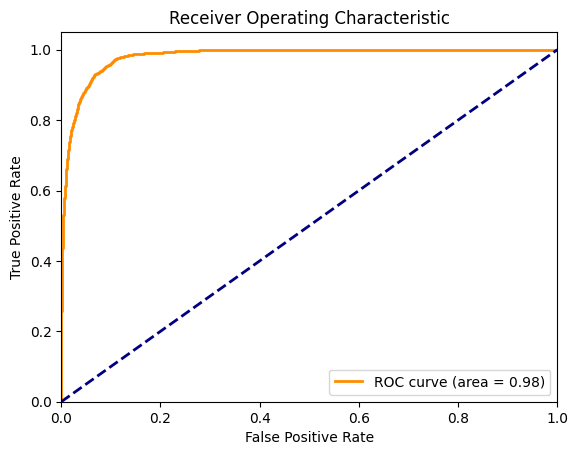

In [396]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr, tpr, color='darkorange', lw=2,
         label='ROC curve (area = %0.2f)' % area)

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Receiver Operating Characteristic')

plt.legend(loc="lower right")

plt.show()

Model Evaluation: Rankorder & KS Statistics

In [397]:
probabilities=best_model_logistics.predict_proba(x_test_encoded)[:,1]

df_eval=pd.DataFrame({
    'Default_truth': y_test,
    'Default_probability': probabilities
})
df_eval.head()

,Default_truth,Default_probability
19205,0,0.789574
15514,0,0.000009
30367,0,0.022647
35347,0,0.023977
41814,1,0.986334


In [398]:
df_eval['decile'] = pd.qcut(
    df_eval['Default_probability'],
    10,
    labels=False,
    duplicates='drop'
)
df_eval

,Default_truth,Default_probability,decile
19205,0,0.789574,8
15514,0,0.000009,1
30367,0,0.022647,6
35347,0,0.023977,6
41814,1,0.986334,9
...,...,...,...
29297,0,0.001363,5
20567,0,0.000108,3
681,0,0.011628,6
33682,0,0.701151,8


In [399]:
df_grouped = df_eval.groupby('decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Default_probability'].min(),
    'Maximum Probability': x['Default_probability'].max(),
    'Events': x['Default_truth'].sum(),
    'Non-events': x['Default_truth'].count() - x['Default_truth'].sum()
}))

df_grouped.reset_index(inplace=True)

df_grouped

C:\Users\Nandan\AppData\Local\Temp\ipykernel_5940\4039937096.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = df_eval.groupby('decile').apply(lambda x: pd.Series({


,decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,7.367108e-09,0.000002,0.0,1250.0
1,1,2.006560e-06,0.000013,0.0,1250.0
2,2,1.342311e-05,0.000063,0.0,1249.0
3,3,6.297558e-05,0.000290,0.0,1250.0
4,4,2.911482e-04,0.001255,0.0,1250.0
5,5,1.257524e-03,0.006712,0.0,1249.0
6,6,6.718205e-03,0.036729,5.0,1245.0
7,7,3.675028e-02,0.251101,15.0,1234.0
8,8,2.514788e-01,0.813814,167.0,1083.0
9,9,8.140984e-01,1.000000,887.0,363.0


In [400]:
df_grouped['Event_rate']=df_grouped['Events']*100 / (df_grouped['Events']+df_grouped['Non-events'])
df_grouped['Non-event_rate']=df_grouped['Non-events']*100 / (df_grouped['Events']+df_grouped['Non-events'])

In [401]:
df_grouped=df_grouped.sort_values(by='decile', ascending=False).reset_index(drop=True)
df_grouped 

,decile,Minimum Probability,Maximum Probability,Events,Non-events,Event_rate,Non-event_rate
0,9,8.140984e-01,1.000000,887.0,363.0,70.960000,29.040000
1,8,2.514788e-01,0.813814,167.0,1083.0,13.360000,86.640000
2,7,3.675028e-02,0.251101,15.0,1234.0,1.200961,98.799039
3,6,6.718205e-03,0.036729,5.0,1245.0,0.400000,99.600000
4,5,1.257524e-03,0.006712,0.0,1249.0,0.000000,100.000000
5,4,2.911482e-04,0.001255,0.0,1250.0,0.000000,100.000000
6,3,6.297558e-05,0.000290,0.0,1250.0,0.000000,100.000000
7,2,1.342311e-05,0.000063,0.0,1249.0,0.000000,100.000000
8,1,2.006560e-06,0.000013,0.0,1250.0,0.000000,100.000000
9,0,7.367108e-09,0.000002,0.0,1250.0,0.000000,100.000000


In [402]:
df_grouped['Cum_events']=df_grouped['Events'].cumsum()
df_grouped['Cum_non_events']=df_grouped['Non-events'].cumsum()

In [403]:
df_grouped['Cum_event_rate'] = df_grouped['Cum_events'] * 100 / df_grouped['Events'].sum()
df_grouped['Cum_Non_event_rate'] = df_grouped['Cum_non_events'] * 100 / df_grouped['Non-events'].sum()

df_grouped

,decile,Minimum Probability,Maximum Probability,Events,Non-events,Event_rate,Non-event_rate,Cum_events,Cum_non_events,Cum_event_rate,Cum_Non_event_rate
0,9,8.140984e-01,1.000000,887.0,363.0,70.960000,29.040000,887.0,363.0,82.588454,3.177799
1,8,2.514788e-01,0.813814,167.0,1083.0,13.360000,86.640000,1054.0,1446.0,98.137803,12.658671
2,7,3.675028e-02,0.251101,15.0,1234.0,1.200961,98.799039,1069.0,2680.0,99.534451,23.461437
3,6,6.718205e-03,0.036729,5.0,1245.0,0.400000,99.600000,1074.0,3925.0,100.000000,34.360501
4,5,1.257524e-03,0.006712,0.0,1249.0,0.000000,100.000000,1074.0,5174.0,100.000000,45.294581
5,4,2.911482e-04,0.001255,0.0,1250.0,0.000000,100.000000,1074.0,6424.0,100.000000,56.237416
6,3,6.297558e-05,0.000290,0.0,1250.0,0.000000,100.000000,1074.0,7674.0,100.000000,67.180250
7,2,1.342311e-05,0.000063,0.0,1249.0,0.000000,100.000000,1074.0,8923.0,100.000000,78.114331
8,1,2.006560e-06,0.000013,0.0,1250.0,0.000000,100.000000,1074.0,10173.0,100.000000,89.057165
9,0,7.367108e-09,0.000002,0.0,1250.0,0.000000,100.000000,1074.0,11423.0,100.000000,100.000000


In [404]:
(899+160)/(899+161+9+5)

0.9860335195530726

In [405]:
df_grouped['KS']=abs(df_grouped['Cum_event_rate'] - df_grouped['Cum_Non_event_rate'])
df_grouped

,decile,Minimum Probability,Maximum Probability,Events,Non-events,Event_rate,Non-event_rate,Cum_events,Cum_non_events,Cum_event_rate,Cum_Non_event_rate,KS
0,9,8.140984e-01,1.000000,887.0,363.0,70.960000,29.040000,887.0,363.0,82.588454,3.177799,79.410655
1,8,2.514788e-01,0.813814,167.0,1083.0,13.360000,86.640000,1054.0,1446.0,98.137803,12.658671,85.479132
2,7,3.675028e-02,0.251101,15.0,1234.0,1.200961,98.799039,1069.0,2680.0,99.534451,23.461437,76.073013
3,6,6.718205e-03,0.036729,5.0,1245.0,0.400000,99.600000,1074.0,3925.0,100.000000,34.360501,65.639499
4,5,1.257524e-03,0.006712,0.0,1249.0,0.000000,100.000000,1074.0,5174.0,100.000000,45.294581,54.705419
5,4,2.911482e-04,0.001255,0.0,1250.0,0.000000,100.000000,1074.0,6424.0,100.000000,56.237416,43.762584
6,3,6.297558e-05,0.000290,0.0,1250.0,0.000000,100.000000,1074.0,7674.0,100.000000,67.180250,32.819750
7,2,1.342311e-05,0.000063,0.0,1249.0,0.000000,100.000000,1074.0,8923.0,100.000000,78.114331,21.885669
8,1,2.006560e-06,0.000013,0.0,1250.0,0.000000,100.000000,1074.0,10173.0,100.000000,89.057165,10.942835
9,0,7.367108e-09,0.000002,0.0,1250.0,0.000000,100.000000,1074.0,11423.0,100.000000,100.000000,0.000000


Show to this model to business presentation

Save the Model

In [406]:
x_test_encoded.head(2)

,age,number_of_open_accounts,credit_utilization_ratio,loan_tenure_months,Loan_to_Income,delinquency_ratio,avg_dpd_per_delinquent_months,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
19205,0.346154,0.333333,0.989899,0.754717,0.548701,0.0,0.0,True,False,False
15514,0.480769,1.000000,0.323232,0.226415,0.219342,0.0,0.0,True,False,False


In [407]:
x_test_encoded.columns

Index(['age', 'number_of_open_accounts', 'credit_utilization_ratio',
       'loan_tenure_months', 'Loan_to_Income', 'delinquency_ratio',
       'avg_dpd_per_delinquent_months', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [408]:
cols_to_scale

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'Loan_to_Income', 'delinquency_ratio', 'avg_dpd_per_delinquent_months'],
      dtype='object')

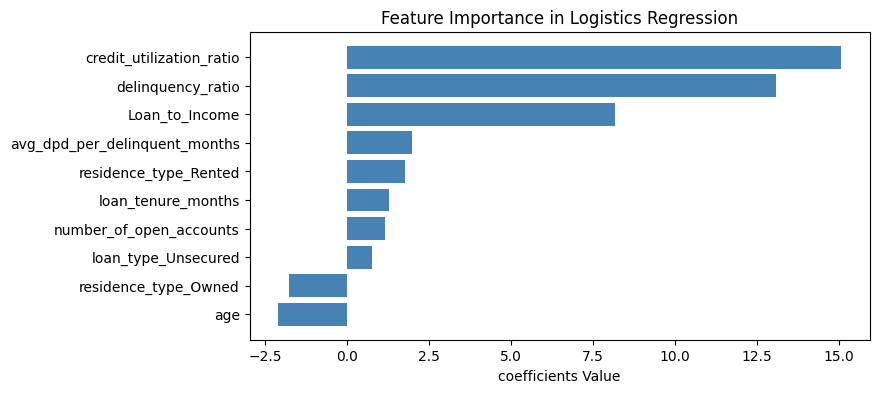

In [409]:
final_model= best_model_logistics

feature_importance= final_model.coef_[0]

# create a DataFrame for easier handling
coef_df= pd.DataFrame(feature_importance, index=x_train_encoded.columns, columns=['Coefficients'])

# sort the coefficients for better visulaization
coef_df=coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting

plt.figure(figsize=(8,4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('coefficients Value')
plt.title('Feature Importance in Logistics Regression')
plt.show()

In [410]:
import os
from joblib import dump

# create folder if it doesn't exist
os.makedirs("artifacts", exist_ok=True)

model_data = {
    'model': final_model,
    'features': x_train_encoded.columns,
    'scaler': scalar,
    'cols_to_scale': cols_to_scale
}

dump(model_data, "artifacts/model_data.joblib")

['artifacts/model_data.joblib']

In [411]:
final_model.coef_, final_model.intercept_

(array([[-2.11684699,  1.14277642, 15.06735923,  1.27306902,  8.16072024,
         13.07976757,  1.98541189, -1.76718681,  1.75961426,  0.77053212]]),
 array([-16.91239573]))

In [412]:
gini_coefficients=2* area -1

print("AUC", area)
print("Gini Coefficient:", gini_coefficients)

AUC 0.9819101290463833
Gini Coefficient: 0.9638202580927666


AUC of 0.98: The model is very good at distinguishing between events and non-events.

Gini coefficient of 0.96: This further confirms that the model is highly effective in its predictions, with almost perfect rank ordering capability.

The Gini coefficient ranges from -1 to 1, where a value closer to 1 signifies a perfect model.

O indicates a model with no discriminative power and -1 signifies a perfectly incorrect model.
